# Classification d'articles de presse français

### Master Executive IA & Data Science

**Auteur :** Xuan PENG et Frédéric DELCROIX

---

#### **Introduction**
Ce rapport présente une étude comparative de modèles de langage pré-entraînés pour la classification automatique d'articles de presse en français. L'objectif principal est d'évaluer les performances de deux architectures Transformer de référence : **CamemBERT** et **XLM-RoBERTa**, sur une tâche de classification multi-classe à 13 catégories thématiques.

#### **Contexte et problématique**
La classification automatique d'articles de presse représente un enjeu pour les médias et les agrégateurs de contenu. Il est crucial de disposer d'outils capables de catégoriser efficacement les articles pour faciliter leur organisation, leur recherche et leur recommandation aux lecteurs.

Les modèles de type BERT ont révolutionné le traitement automatique du langage naturel en introduisant l'apprentissage bidirectionnel contextuel. Pour le français, plusieurs modèles spécialisés ont été développés, offrant des performances supérieures aux modèles multilingues génériques sur certaines tâches.

#### **Objectifs du projet**
1.	Comparer les performances de deux modèles Transformer sur une tâche de classification d'articles de presse français
2.	Évaluer l'impact de la spécialisation linguistique (modèles français vs multilingue)
3.	Analyser les performances par catégorie et identifier les sources d'erreurs
4.	Proposer des pistes d'amélioration pour optimiser les résultats

---

#### **Table des matières**

1. Description des modèles
2. Description du dataset et des catégories
3. Installation et imports
4. Chargement et exploration des données
5. Système de classification hiérarchique
6. Préparation des données
7. Entraînement des modèles
8. Comparaison et analyse
9. Conclusion

---

#### **1. Description des modèles**

##### **1.1 CamemBERT**

CamemBERT est un modèle de langage basé sur l'architecture RoBERTa, spécifiquement pré-entraîné sur un large corpus de textes français. Développé par l'équipe de recherche FAIR (Facebook AI Research) en collaboration avec Inria, il représente l'état de l'art pour de nombreuses tâches de TAL en français.

| Caractéristique | Valeur |
|----------------|--------|
| **Architecture** | RoBERTa |
| **Paramètres** | ~110M |
| **Couches** | 12 |
| **Dimension cachée** | 768 |
| **Vocabulaire** | 32K tokens (BPE) |
| **Corpus** | OSCAR (138 Go français) |
| **Langue** | Français |

##### **1.2 XLM-RoBERTa**

XLM-RoBERTa est un modèle multilingue développé par Facebook AI, capable de traiter 100 langues différentes. Il représente une approche différente : plutôt que de spécialiser un modèle pour une langue, il apprend des représentations universelles à partir d'un corpus massif multilingue.

| Caractéristique | Valeur |
|----------------|--------|
| **Architecture** | RoBERTa |
| **Paramètres** | ~270M |
| **Couches** | 12 |
| **Dimension cachée** | 768 |
| **Vocabulaire** | 250K tokens |
| **Corpus** | CommonCrawl (2.5 To) |
| **Langues** | 100 langues |

##### **1.3 Comparatif**

| Aspect | CamemBERT | XLM-RoBERTa |
|--------|-----------|-------------|
| **Spécialisation** | Français | Multilingue |
| **Taille** | Léger | Lourd |
| **Tokenizer** | SentencePiece | SentencePiece |

---

#### **2. Description du dataset et des catégories**

##### **2.1 Dataset**

Le dataset utilisé est **« diverse_french_news »**, disponible sur Hugging Face. Il contient des articles de presse française provenant de plusieurs sources, avec les champs suivants :
- title : Titre de l'article
- description : Chapeau ou résumé de l'article
- text : Contenu complet de l'article
- domain : Source de l'article (ex: lemonde.fr)
- url

Dans ce projet, je filtre uniquement sur le domaine **« lemonde.fr »** qui permet d'assurer le temps d'exécution et une cohérence éditoriale et stylistique dans le corpus.  

#### **2.2 Les 13 catégories et leurs sous-catégories**

J'ai ajouté 13 catégories couvrant l'ensemble des rubriques d'un journal généraliste. Ces 13 catégories présentent des niveaux de difficulté variables pour la classification. Certaines catégories comme « Sport » ou « Météo » ont un vocabulaire très distinctif, tandis que d'autres comme « Monde » et « Europe » peuvent se chevaucher significativement dans leur contenu.

| # | Catégorie | Sous-catégories |
|---|-----------|-----------------|
| 1 | **Monde** | Conflits, Diplomatie, Asie, Amériques, Afrique, Moyen-Orient, Océanie, ONU, Terrorisme, Migrations |
| 2 | **Europe** | Union Européenne, Brexit, Allemagne, Italie, Espagne, Royaume-Uni, Russie, Ukraine, Balkans, Scandinavie |
| 3 | **Faits-divers** | Accidents, Crimes, Incendies, Disparitions, Catastrophes, Agressions, Cambriolages, Arnaques, Procès, Justice |
| 4 | **Politique** | Élections, Gouvernement, Parlement, Réformes, Partis, Président, Ministres, Lois, Sondages, Municipales |
| 5 | **Société** | Éducation, Famille, Religion, Immigration, Inégalités, Logement, Emploi, Retraites, Manifestations, Droits |
| 6 | **Environnement** | Climat, Pollution, Biodiversité, Énergies, Recyclage, Agriculture, Océans, Forêts, COP, Écologie |
| 7 | **Sport** | Football, Tennis, Rugby, Cyclisme, JO, Athlétisme, Basket, F1, Natation, Handball |
| 8 | **Culture** | Cinéma, Musique, Littérature, Théâtre, Art, Festivals, Télévision, Séries, Patrimoine, Mode |
| 9 | **Éco/Conso** | Entreprises, Bourse, Emploi, Immobilier, Consommation, Inflation, Commerce, Startups, Industrie, Banques |
| 10 | **Santé** | Maladies, Vaccins, Hôpitaux, Médicaments, Épidémies, Recherche, Bien-être, Nutrition, Psychologie, Handicap |
| 11 | **Sciences & Tech** | IA, Espace, Numérique, Découvertes, Innovation, Smartphones, Internet, Robots, Génétique, Énergie |
| 12 | **Météo** | Prévisions, Canicule, Tempêtes, Neige, Inondations, Sécheresse, Orages, Verglas, Vigilance, Saisons |
| 13 | **Jeux** | Loto, Euromillions, Jeux vidéo, Casino, Paris sportifs, Concours, Quiz, Grattage, Jackpot, Gaming |

---

#### **3. Installation et imports**
Cette section présente les bibliothèques nécessaires à l'exécution du projet et la configuration de l'environnement d'exécution.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')
import gc
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset

from transformers import (
    CamembertTokenizer, 
    CamembertModel,
    XLMRobertaTokenizer,
    XLMRobertaModel,
)

from sklearn.metrics import (
    accuracy_score, 
    f1_score, 
    classification_report, 
    confusion_matrix,
    precision_recall_fscore_support
)

from tqdm.notebook import tqdm

# Configuration GPU
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU : {torch.cuda.get_device_name(0)}")

2026-01-10 09:14:46.489697: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1768036486.684551      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1768036486.737964      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1768036487.188107      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1768036487.188147      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1768036487.188150      55 computation_placer.cc:177] computation placer alr

Device : cuda
GPU : Tesla P100-PCIE-16GB


---

#### **4. Chargement et exploration des données**
Le dataset est déjà divisé en trois ensembles (train/validation/test). On peut charger directement depuis le hub Hugging Face.

In [2]:
# Chargement du dataset
splits = {
    'train': 'summarization_train.csv',
    'validation': 'summarization_validation.csv',
    'test': 'summarization_test.csv'
}

df_train = pd.read_csv("hf://datasets/gustavecortal/diverse_french_news/" + splits["train"])
df_val = pd.read_csv("hf://datasets/gustavecortal/diverse_french_news/" + splits["validation"])
df_test = pd.read_csv("hf://datasets/gustavecortal/diverse_french_news/" + splits["test"])

print(f"Train : {len(df_train)} articles")
print(f"Validation : {len(df_val)} articles")
print(f"Test : {len(df_test)} articles")

Train : 335407 articles
Validation : 10000 articles
Test : 10000 articles


In [3]:
df_train["domain"].value_counts()

domain
francetvinfo.fr              35189
lalibre.be                   18352
dhnet.be                     18159
la-croix.com                 18070
lemonde.fr                   17980
lci.fr                       14319
melty.fr                     13777
bfmtv.com                    12787
clubic.com                   12423
rtl.fr                        9155
lefigaro.fr                   8723
huffingtonpost.fr             8528
lepetitjournal.com            8365
liberation.fr                 7431
voici.fr                      7353
rtbf.be                       7040
femmeactuelle.fr              6844
lejdd.fr                      6691
lexpress.fr                   5909
franceinter.fr                5774
futura-sciences.com           5715
boursorama.com                5449
courrierinternational.com     5275
marianne.net                  5111
europe1.fr                    4906
lesoir.be                     4849
demotivateur.fr               4835
elle.fr                       4644
slate.fr     

In [ ]:
# Filtrage et nettoyage
print("Colonnes :", df_train.columns.tolist())

df_train = df_train[df_train["domain"] == "lemonde.fr"]
df_val = df_val[df_val["domain"] == "lemonde.fr"]
df_test = df_test[df_test["domain"] == "lemonde.fr"]

columns_to_keep = ['title', 'description', 'text']
available_columns = [col for col in columns_to_keep if col in df_train.columns]

df_train = df_train[available_columns].dropna()
df_val = df_val[available_columns].dropna()
df_test = df_test[available_columns].dropna()

print(f"\nAprès nettoyage : {len(df_train)} / {len(df_val)} / {len(df_test)}")
df_train.head()

Colonnes : ['title', 'description', 'text', 'domain', 'url']

Après nettoyage : 17980 / 538 / 550


,title,description,text
0,"Le gendarme Pyrrhocoris apterus , l'insecte le...",De son nom scientifique Pyrrhocoris apterus si...,"Tout le monde connait les gendarmes, notamment..."
2,Donald Trump accorde la grâce à l’un de ses an...,En tout 73 personnes ont été graciées et 70 on...,C’est une litanie de 143 noms qui s’étend sur ...
7,Le patron du réseau conservateur Parler démis ...,La présidente d’une commission parlementaire a...,"John Matze, le patron du réseau social conserv..."
26,Covid-19 : comment Gilead a vendu son remdésiv...,"Un contrat a été passé avec la Commission, alo...",Une ampoule d’antiviral remdésivir du laborato...
38,""" 100 rock "", une nouvelle ligne pour relancer...",La Ville de Paris va abandonner la diversifica...,La façade extérieure du Bataclan après sa réno...


In [5]:
# Exemple d'article
sample = df_train.iloc[0]
print("EXEMPLE D'ARTICLE")
print("-" * 80)
for col in available_columns:
    print(f"\n[{col.upper()}]")
    print(str(sample[col])[:400])

EXEMPLE D'ARTICLE
--------------------------------------------------------------------------------

[TITLE]
Le gendarme Pyrrhocoris apterus , l'insecte le plus inoffensif

[DESCRIPTION]
De son nom scientifique Pyrrhocoris apterus signifiant en grec feu et punaise , le pyrrhocore a plusieurs noms familiers : gendarme, bien sûr, mais aussi suisse. Ne tentez pas de l'éradiquer du jardin, ils n'en est pas un ravageur.

[TEXT]
Tout le monde connait les gendarmes, notamment les enfants qui les observent souvent, y compris en classe d'école primaire, afin d'étudier le comportement de ces insectes. Il vit dans les régions à climat tempéré comme c'est le cas en Europe et autour du bassin méditerranéen, mais il ne s'aventure pas en montagne. Le gendarme ou pyrrhocore De son nom scientifique Pyrrhocoris apterus signifiant en 


---

#### **5. Système de classification hiérarchique**
En l'absence de labels dans le dataset original, j'ai implémenté la classification par mots-clés pour attribuer automatiquement une catégorie à chaque article.
Les mappings CATEGORY_TO_ID et ID_TO_CATEGORY permettent de convertir facilement entre les noms de catégories et leurs indices numériques pour l'entraînement des modèles.

##### **5.1 Définition des 13 catégories et mots-clés**

In [ ]:
CATEGORIES_KEYWORDS = {
    "Monde": [
        "international", "mondial", "étranger", "diplomatie", "ONU", "OTAN",
        "sommet", "conflit", "guerre", "paix", "traité", "ambassade",
        "géopolitique", "frontière", "migration", "réfugiés", "humanitaire",
        "États-Unis", "Chine", "Russie", "Moyen-Orient", "Afrique", "Asie",
        "Amérique latine", "sanctions", "coalition", "négociations"
    ],
    
    "Europe": [
        "Union européenne", "UE", "Bruxelles", "Commission européenne",
        "Parlement européen", "BCE", "euro", "Schengen", "Brexit",
        "Allemagne", "Italie", "Espagne", "directive", "règlement européen",
        "fonds européens", "élargissement", "souveraineté", "Eurozone",
        "traité de Lisbonne", "Conseil européen", "Ursula von der Leyen"
    ],
    
    "Faits-divers": [
        "accident", "incendie", "meurtre", "agression", "vol", "cambriolage",
        "disparition", "enquête", "police", "gendarmerie", "victime",
        "suspect", "arrestation", "garde à vue", "procès", "tribunal",
        "drame", "tragédie", "noyade", "collision", "braquage", "escroquerie",
        "violences", "homicide", "autopsie", "témoins"
    ],
    
    "Politique": [
        "gouvernement", "Élysée", "Matignon", "Assemblée nationale", "Sénat",
        "président", "premier ministre", "ministre", "député", "sénateur",
        "élection", "vote", "scrutin", "campagne", "parti", "majorité",
        "opposition", "réforme", "loi", "projet de loi", "amendement",
        "motion de censure", "dissolution", "remaniement", "gauche", "droite",
        "Macron", "Renaissance", "RN", "LFI", "PS", "LR"
    ],
    
    "Société": [
        "éducation", "école", "université", "logement", "emploi", "chômage",
        "retraite", "famille", "jeunesse", "seniors", "inégalités",
        "discrimination", "racisme", "féminisme", "LGBT", "religion",
        "laïcité", "immigration", "intégration", "banlieue", "ruralité",
        "associations", "bénévolat", "solidarité", "pauvreté", "SDF"
    ],
    
    "Environnement": [
        "climat", "réchauffement", "carbone", "émissions", "CO2",
        "biodiversité", "écologie", "pollution", "déchets", "recyclage",
        "énergies renouvelables", "solaire", "éolien", "nucléaire",
        "transition énergétique", "COP", "GIEC", "canicule", "sécheresse",
        "inondations", "catastrophe naturelle", "forêt", "océan", "pesticides",
        "agriculture durable", "extinction", "espèces menacées"
    ],
    
    "Sport": [
        "football", "rugby", "tennis", "cyclisme", "athlétisme", "natation",
        "basket", "handball", "Jeux olympiques", "Coupe du monde", "Ligue 1",
        "Champions League", "Roland-Garros", "Tour de France", "match",
        "victoire", "défaite", "champion", "médaille", "transfert",
        "entraîneur", "équipe", "stade", "compétition", "finale", "PSG", "OM"
    ],
    
    "Culture": [
        "cinéma", "film", "musique", "concert", "théâtre", "exposition",
        "musée", "littérature", "livre", "roman", "festival", "Cannes",
        "César", "artiste", "acteur", "réalisateur", "album", "chanson",
        "danse", "opéra", "patrimoine", "architecture", "peinture",
        "sculpture", "photographie", "série", "Netflix", "streaming"
    ],
    
    "Éco/Conso": [
        "économie", "croissance", "PIB", "inflation", "pouvoir d'achat",
        "entreprise", "bourse", "CAC 40", "actions", "investissement",
        "banque", "crédit", "taux d'intérêt", "commerce", "consommation",
        "prix", "promotion", "soldes", "rappel produit", "arnaque",
        "startup", "licenciement", "grève", "salaire", "impôts", "fiscalité"
    ],
    
    "Santé": [
        "maladie", "virus", "épidémie", "pandémie", "Covid", "vaccin",
        "hôpital", "médecin", "soignant", "infirmier", "urgences",
        "médicament", "traitement", "cancer", "diabète", "Alzheimer",
        "prévention", "dépistage", "Sécurité sociale", "mutuelle",
        "nutrition", "obésité", "tabac", "alcool", "santé mentale", "OMS"
    ],
    
    "Sciences & Tech": [
        "intelligence artificielle", "IA", "robot", "algorithme",
        "numérique", "internet", "smartphone", "application", "cybersécurité",
        "données", "innovation", "recherche", "découverte", "espace",
        "NASA", "SpaceX", "satellite", "fusée", "quantique", "ADN",
        "génétique", "biotechnologie", "CNRS", "laboratoire", "expérience",
        "ChatGPT", "deepfake", "blockchain", "5G"
    ],
    
    "Météo": [
        "température", "pluie", "neige", "vent", "orage", "soleil",
        "nuages", "brouillard", "verglas", "gel", "canicule", "chaleur",
        "froid", "tempête", "cyclone", "ouragan", "prévisions", "bulletin",
        "Météo France", "vigilance", "alerte orange", "alerte rouge",
        "anticyclone", "dépression", "humidité", "degrés"
    ],
    
    "Jeux": [
        "jeu vidéo", "gaming", "console", "PlayStation", "Xbox", "Nintendo",
        "PC", "esport", "joueur", "streamer", "Twitch", "loto", "euromillions",
        "jackpot", "tirage", "gagnant", "casino", "paris sportifs", "PMU",
        "FDJ", "grattage", "loterie", "mise", "cote", "poker",
        "jeux de société", "puzzle", "mots croisés"
    ]
}

CATEGORY_TO_ID = {cat: idx for idx, cat in enumerate(list(CATEGORIES_KEYWORDS.keys()))}
ID_TO_CATEGORY = {idx: cat for cat, idx in CATEGORY_TO_ID.items()}

print("Catégories définies (13 catégories) :")
for cat, idx in CATEGORY_TO_ID.items():
    n_keywords = len(CATEGORIES_KEYWORDS.get(cat, []))
    print(f"  {idx}: {cat} ({n_keywords} mots-clés)")

Catégories définies (10 catégories) :
  0: Monde (27 mots-clés)
  1: Europe (21 mots-clés)
  2: Faits-divers (26 mots-clés)
  3: Politique (32 mots-clés)
  4: Société (26 mots-clés)
  5: Environnement (27 mots-clés)
  6: Sport (27 mots-clés)
  7: Culture (28 mots-clés)
  8: Éco/Conso (26 mots-clés)
  9: Santé (26 mots-clés)
  10: Sciences & Tech (29 mots-clés)
  11: Météo (26 mots-clés)
  12: Jeux (28 mots-clés)


In [ ]:
def classify_article(title, description):
    """
    Classifie un article en fonction des mots-clés présents dans le titre et la description.
    
    L'algorithme de scoring attribue un poids triple aux mots-clés présents dans le titre. 
    Cette heuristique reflète l'importance éditoriale du titre qui résume généralement le sujet principal de l'article. 
    La catégorie avec le score le plus élevé est retenue.
    """
    text = f"{title} {description}".lower()
    title_lower = str(title).lower()
    
    scores = {}
    for category, keywords in CATEGORIES_KEYWORDS.items():
        score = 0
        for keyword in keywords:
            if keyword in text:
                score += 1
            if keyword in title_lower:
                score += 3  
        scores[category] = score
    
    return max(scores, key=scores.get)
    
# Tests
test_cases = [
    ("L'équipe de France de football remporte la victoire", "Match incroyable au stade"),
    ("Macron annonce une nouvelle réforme", "Le président a présenté son projet de loi"),
    ("Festival de Cannes : les films en compétition", "Les acteurs et réalisateurs présents"),
    ("Manifestation contre la réforme des retraites", "Des milliers de personnes dans la rue"),
    ("Découverte d'une nouvelle planète", "Les chercheurs de la NASA annoncent")
]

print("Tests de classification :")
for title, desc in test_cases:
    cat = classify_article(title, desc)
    print(f"  '{title[:50]}...' → {cat}")

Tests de classification :
  'L'équipe de France de football remporte la victoir...' → Sport
  'Macron annonce une nouvelle réforme...' → Politique
  'Festival de Cannes : les films en compétition...' → Culture
  'Manifestation contre la réforme des retraites...' → Politique
  'Découverte d'une nouvelle planète...' → Sciences & Tech


In [8]:
# Appliquer la classification à tous les datasets
def add_labels(df):
    title_col = 'title' if 'title' in df.columns else df.columns[0]
    desc_col = 'description' if 'description' in df.columns else (
        df.columns[1] if len(df.columns) > 1 else df.columns[0]
    )
    
    df['category'] = df.apply(
        lambda row: classify_article(row[title_col], row[desc_col]), 
        axis=1
    )
    df['label'] = df['category'].map(CATEGORY_TO_ID)
    return df

df_train = add_labels(df_train)
df_val = add_labels(df_val)
df_test = add_labels(df_test)

df_train.head()

,title,description,text,category,label
0,"Le gendarme Pyrrhocoris apterus , l'insecte le...",De son nom scientifique Pyrrhocoris apterus si...,"Tout le monde connait les gendarmes, notamment...",Monde,0
2,Donald Trump accorde la grâce à l’un de ses an...,En tout 73 personnes ont été graciées et 70 on...,C’est une litanie de 143 noms qui s’étend sur ...,Monde,0
7,Le patron du réseau conservateur Parler démis ...,La présidente d’une commission parlementaire a...,"John Matze, le patron du réseau social conserv...",Faits-divers,2
26,Covid-19 : comment Gilead a vendu son remdésiv...,"Un contrat a été passé avec la Commission, alo...",Une ampoule d’antiviral remdésivir du laborato...,Europe,1
38,""" 100 rock "", une nouvelle ligne pour relancer...",La Ville de Paris va abandonner la diversifica...,La façade extérieure du Bataclan après sa réno...,Monde,0


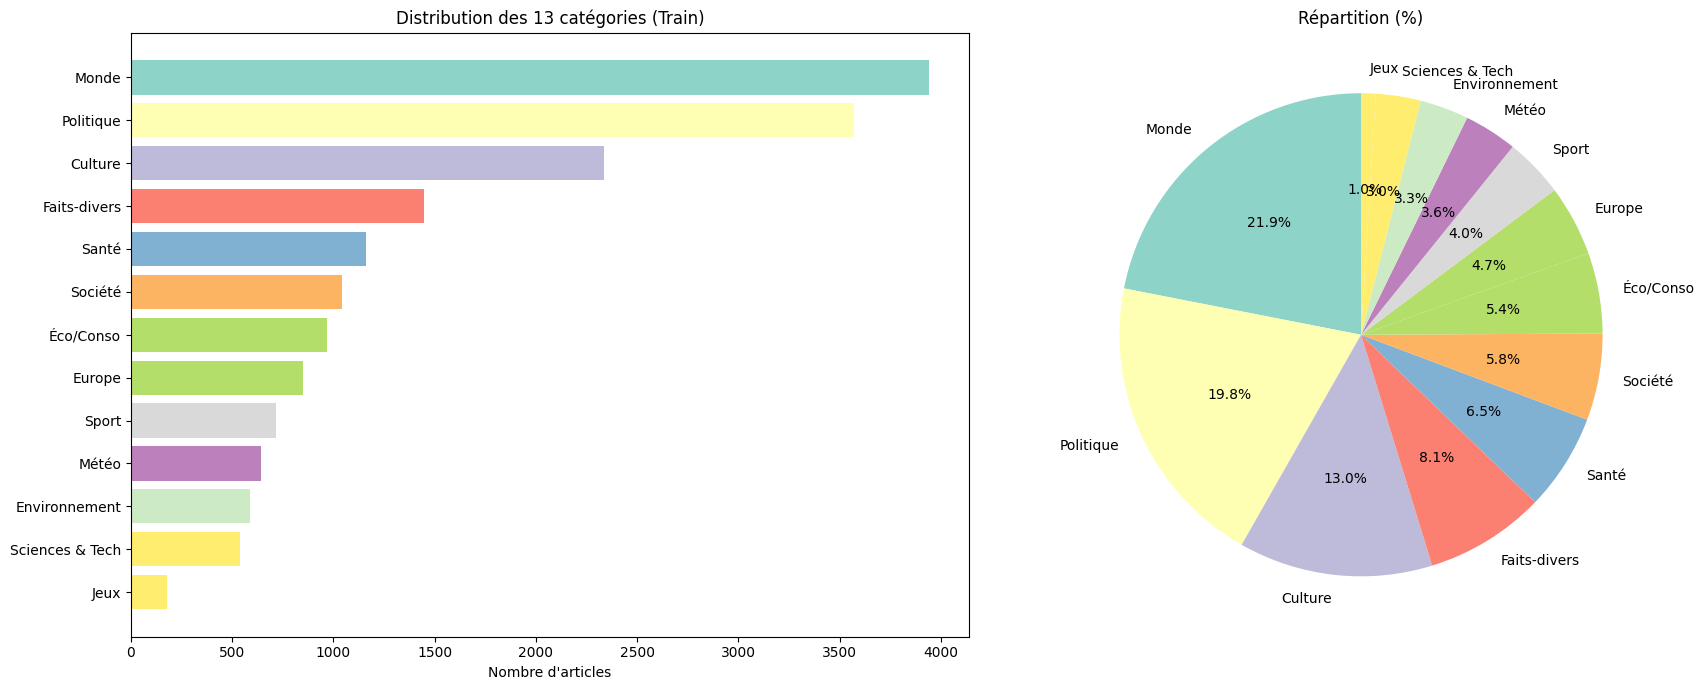

In [9]:
# Visualisation de la distribution
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

category_counts = df_train['category'].value_counts()
colors = plt.cm.Set3(np.linspace(0, 1, len(category_counts)))

# Bar plot
bars = axes[0].barh(category_counts.index, category_counts.values, color=colors)
axes[0].set_xlabel("Nombre d'articles")
axes[0].set_title('Distribution des 13 catégories (Train)')
axes[0].invert_yaxis()

# Pie chart
axes[1].pie(category_counts.values, labels=category_counts.index, autopct='%1.1f%%', 
            colors=colors, startangle=90)
axes[1].set_title('Répartition (%)')

plt.tight_layout()
plt.show()

Ce graphique révèle un déséquilibre significatif entre les catégories. Les catégories **« Monde »**, **« Politique »** et **« Culture »** sont surreprésentées, tandis que « Météo » et « Jeux » sont sous-représentées. Ce déséquilibre peut biaiser l'apprentissage vers les classes majoritaires et nécessite une stratégie d'équilibrage.

In [10]:
# Vérification de l'équilibre des classes
print("ANALYSE DE L'ÉQUILIBRE DES CLASSES")

for split_name, df in [('Train', df_train), ('Validation', df_val), ('Test', df_test)]:
    print(f"\n{split_name} set :")
    counts = df['category'].value_counts()
    for cat in CATEGORY_TO_ID.keys():
        count = counts.get(cat, 0)
        pct = 100 * count / len(df)
        print(f"  {cat:12} : {count:5} ({pct:5.1f}%)")

ANALYSE DE L'ÉQUILIBRE DES CLASSES

Train set :
  Monde        :  3942 ( 21.9%)
  Europe       :   852 (  4.7%)
  Faits-divers :  1448 (  8.1%)
  Politique    :  3569 ( 19.8%)
  Société      :  1043 (  5.8%)
  Environnement :   587 (  3.3%)
  Sport        :   715 (  4.0%)
  Culture      :  2335 ( 13.0%)
  Éco/Conso    :   970 (  5.4%)
  Santé        :  1163 (  6.5%)
  Sciences & Tech :   539 (  3.0%)
  Météo        :   641 (  3.6%)
  Jeux         :   176 (  1.0%)

Validation set :
  Monde        :   114 ( 21.2%)
  Europe       :    31 (  5.8%)
  Faits-divers :    58 ( 10.8%)
  Politique    :    95 ( 17.7%)
  Société      :    35 (  6.5%)
  Environnement :    18 (  3.3%)
  Sport        :    17 (  3.2%)
  Culture      :    62 ( 11.5%)
  Éco/Conso    :    22 (  4.1%)
  Santé        :    35 (  6.5%)
  Sciences & Tech :    22 (  4.1%)
  Météo        :    21 (  3.9%)
  Jeux         :     8 (  1.5%)

Test set :
  Monde        :   119 ( 21.6%)
  Europe       :    21 (  3.8%)
  Faits-divers :  

In [11]:
# Exemples par catégorie
print("EXEMPLES PAR CATÉGORIE")
print("-"*80)

title_col = 'title' if 'title' in df_train.columns else df_train.columns[0]

for category in CATEGORY_TO_ID.keys():
    examples = df_train[df_train['category'] == category]
    if len(examples) > 0:
        print(f"\n--- {category.upper()} ({len(examples)} articles) ---")
        for i, (_, row) in enumerate(examples.head(2).iterrows()):
            title_text = str(row[title_col])
            print(f"  • {title_text[:80]}..." if len(title_text) > 80 else f"  • {title_text}")

EXEMPLES PAR CATÉGORIE
--------------------------------------------------------------------------------

--- MONDE (3942 articles) ---
  • Le gendarme Pyrrhocoris apterus , l'insecte le plus inoffensif
  • Donald Trump accorde la grâce à l’un de ses anciens conseillers, Steve Bannon, e...

--- EUROPE (852 articles) ---
  • Covid-19 : comment Gilead a vendu son remdésivir à l’Europe
  • L’Etat de droit, meilleure protection pour les droits LGBT en Europe

--- FAITS-DIVERS (1448 articles) ---
  • Le patron du réseau conservateur Parler démis de ses fonctions
  • " La crise climatique serait un accident au ralenti "

--- POLITIQUE (3569 articles) ---
  • Grand âge : " Préserver l’autonomie et repousser la survenue du déclin cognitif ...
  • Les prétendants à l’élection présidentielle de 2022 à la recherche du " vivre-en...

--- SOCIÉTÉ (1043 articles) ---
  • " Pouvoir bénéficier du RSA dès 18 ans : une nécessité en ces temps de crise "
  • Comment lutter contre la larve du hanneton ?

--

---

#### **6. Préparation des données**
Ces hyperparamètres sont des valeurs standards pour le fine-tuning de modèles BERT. Le learning rate de 3e-5 est recommandé par les auteurs de BERT. La limitation à 5000 échantillons d'entraînement représente un compromis entre temps de calcul et représentativité des données

In [12]:
# Paramètres
NUM_CLASSES = len(CATEGORY_TO_ID)
MAX_LENGTH = 256
BATCH_SIZE = 16
N_EPOCHS = 3
LEARNING_RATE = 3e-5

# Limiter le nombre d'exemples (ajuster selon les ressources)
N_TRAIN_SAMPLES = min(5000, len(df_train))
N_VAL_SAMPLES = min(1000, len(df_val))
N_TEST_SAMPLES = min(1000, len(df_test))

print(f"Nombre de classes : {NUM_CLASSES}")
print(f"\nParamètres d'entraînement :")
print(f"  - Max length : {MAX_LENGTH}")
print(f"  - Batch size : {BATCH_SIZE}")
print(f"  - Epochs : {N_EPOCHS}")
print(f"  - Learning rate : {LEARNING_RATE}")
print(f"  - Train samples : {N_TRAIN_SAMPLES}")

Nombre de classes : 13

Paramètres d'entraînement :
  - Max length : 256
  - Batch size : 16
  - Epochs : 3
  - Learning rate : 3e-05
  - Train samples : 5000


**L'échantillonnage équilibré (balanced sampling)** est essentiel pour éviter que le modèle ne favorise les classes majoritaires. En prélevant un nombre égal d'exemples par classe, on force le modèle à apprendre des représentations discriminantes pour toutes les catégories, même les moins fréquentes.

In [13]:
# Sous-échantillonnage équilibré
def balanced_sample(df, n_samples, random_state=42):
    n_per_class = n_samples // NUM_CLASSES
    samples = []
    
    for category in CATEGORY_TO_ID.keys():
        cat_df = df[df['category'] == category]
        n_to_sample = min(len(cat_df), n_per_class)
        if n_to_sample > 0:
            samples.append(cat_df.sample(n=n_to_sample, random_state=random_state))
    
    return pd.concat(samples).sample(frac=1, random_state=random_state).reset_index(drop=True)

df_train_sample = balanced_sample(df_train, N_TRAIN_SAMPLES)
df_val_sample = balanced_sample(df_val, N_VAL_SAMPLES)
df_test_sample = balanced_sample(df_test, N_TEST_SAMPLES)

print("Distribution après échantillonnage équilibré :")
print(df_train_sample['category'].value_counts())

Distribution après échantillonnage équilibré :
category
Santé              384
Météo              384
Sport              384
Europe             384
Culture            384
Sciences & Tech    384
Monde              384
Environnement      384
Société            384
Politique          384
Faits-divers       384
Éco/Conso          384
Jeux               176
Name: count, dtype: int64


**La classe Dataset** encapsule la logique de prétraitement. Le titre et la description sont concaténés avec un token **[SEP]** qui permet au modèle de distinguer les deux parties. Le padding et la troncation assurent que toutes les séquences ont la même longueur.

In [ ]:
# Classe Dataset
class FrenchNewsDataset(Dataset):
    def __init__(self, df, tokenizer, max_length=256):
        self.df = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_length = max_length
        self.title_col = 'title' if 'title' in df.columns else df.columns[0]
        self.desc_col = 'description' if 'description' in df.columns else df.columns[0]
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        text = f"{row[self.title_col]} [SEP] {row[self.desc_col]}"
        
        encoding = self.tokenizer(
            text,
            truncation=True,
            max_length=self.max_length,
            padding='max_length',
            return_tensors='pt'
        )
        
        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'labels': torch.tensor(row['label'], dtype=torch.long)
        }

def create_dataloaders(tokenizer, df_train, df_val, df_test, batch_size=16, max_length=256):
    train_dataset = FrenchNewsDataset(df_train, tokenizer, max_length)
    val_dataset = FrenchNewsDataset(df_val, tokenizer, max_length)
    test_dataset = FrenchNewsDataset(df_test, tokenizer, max_length)
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    
    return train_loader, val_loader, test_loader

**L'architecture** est simple : on extrait l'embedding du token **[CLS]** (position 0) qui encode une représentation globale de la séquence, on applique un dropout pour la régularisation, puis une couche linéaire pour la classification.

In [15]:
# Classificateur générique
class TransformerClassifier(nn.Module):
    def __init__(self, base_model, num_classes, dropout_rate=0.3):
        super().__init__()
        self.base_model = base_model
        self.dropout = nn.Dropout(dropout_rate)
        self.classifier = nn.Linear(base_model.config.hidden_size, num_classes)
    
    def forward(self, input_ids, attention_mask, **kwargs):
        outputs = self.base_model(input_ids=input_ids, attention_mask=attention_mask)
        cls_output = outputs.last_hidden_state[:, 0, :]
        cls_output = self.dropout(cls_output)
        logits = self.classifier(cls_output)
        return logits

In [16]:
# Fonctions d'entraînement et d'évaluation
def train_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    for batch in tqdm(dataloader, desc="Training"):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        
        optimizer.zero_grad()
        outputs = model(input_ids, attention_mask)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        predictions = outputs.argmax(dim=1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)
    
    return total_loss / len(dataloader), correct / total

def evaluate(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0
    all_predictions = []
    all_labels = []
    
    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Evaluating"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            
            outputs = model(input_ids, attention_mask)
            loss = criterion(outputs, labels)
            
            total_loss += loss.item()
            predictions = outputs.argmax(dim=1)
            
            all_predictions.extend(predictions.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    accuracy = accuracy_score(all_labels, all_predictions)
    f1 = f1_score(all_labels, all_predictions, average='macro')
    
    return total_loss / len(dataloader), accuracy, f1, all_predictions, all_labels


def train_model(model, train_loader, val_loader, n_epochs, learning_rate, device, model_name="Model"):
    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, eps=1e-8)
    criterion = nn.CrossEntropyLoss()
    
    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': [], 'val_f1': []
    }
    
    print(f"Entraînement de {model_name}")
    print(f"{'-'*60}")
    
    for epoch in range(n_epochs):
        print(f"\nÉpoque {epoch + 1}/{n_epochs}")
        print("-" * 40)
        
        train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, device)
        val_loss, val_acc, val_f1, _, _ = evaluate(model, val_loader, criterion, device)
        
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['val_f1'].append(val_f1)
        
        print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc*100:.2f}%")
        print(f"  Val Loss: {val_loss:.4f} | Val Acc: {val_acc*100:.2f}% | Val F1: {val_f1:.4f}")
    
    return history

---

#### **7. Entraînement des modèles**

##### **7.1 CamemBERT**

In [17]:
# Chargement de CamemBERT
print("Chargement de CamemBERT...")
camembert_tokenizer = CamembertTokenizer.from_pretrained('camembert-base')
camembert_base = CamembertModel.from_pretrained('camembert-base')

print(f"\nConfiguration de CamemBERT :")
print(f"  - Hidden size : {camembert_base.config.hidden_size}")
print(f"  - Num layers : {camembert_base.config.num_hidden_layers}")
print(f"  - Vocab size : {camembert_base.config.vocab_size}")

Chargement de CamemBERT...


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/811k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.40M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/508 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/445M [00:00<?, ?B/s]


Configuration de CamemBERT :
  - Hidden size : 768
  - Num layers : 12
  - Vocab size : 32005


Le modèle camembert-base est chargé depuis le hub Hugging Face avec ses poids pré-entraînés. La dimension cachée de **768** correspond à la taille des embeddings, utilisée ensuite par la couche de classification.

In [18]:
# Test du tokenizer
test_sentence = "Le président de la République a annoncé de nouvelles mesures."
tokens = camembert_tokenizer.tokenize(test_sentence)
print(f"Phrase : {test_sentence}")
print(f"Tokens : {tokens}")
print(f"Nombre de tokens : {len(tokens)}")

Phrase : Le président de la République a annoncé de nouvelles mesures.
Tokens : ['▁Le', '▁président', '▁de', '▁la', '▁République', '▁a', '▁annoncé', '▁de', '▁nouvelles', '▁mesures', '.']
Nombre de tokens : 11


Le **tokenizer SentencePiece** de CamemBERT utilise le préfixe « ▁ » pour indiquer les débuts de mots. Cette tokenization sous-mots permet de gérer les mots rares ou inconnus en les décomposant en unités plus petites

In [19]:
# Création du modèle et DataLoaders
camembert_classifier = TransformerClassifier(camembert_base, NUM_CLASSES)
camembert_classifier.to(DEVICE)

camembert_train_loader, camembert_val_loader, camembert_test_loader = create_dataloaders(
    camembert_tokenizer, df_train_sample, df_val_sample, df_test_sample,
    batch_size=BATCH_SIZE, max_length=MAX_LENGTH
)

print(f"Modèle CamemBERT : {sum(p.numel() for p in camembert_classifier.parameters()):,} paramètres")
print(f"Train batches : {len(camembert_train_loader)}")
print(f"Val batches : {len(camembert_val_loader)}")
print(f"Test batches : {len(camembert_test_loader)}")

Modèle CamemBERT : 110,631,949 paramètres
Train batches : 299
Val batches : 24
Test batches : 24


In [20]:
# Entraînement de CamemBERT
camembert_history = train_model(
    camembert_classifier,
    camembert_train_loader,
    camembert_val_loader,
    n_epochs=N_EPOCHS,
    learning_rate=LEARNING_RATE,
    device=DEVICE,
    model_name="CamemBERT"
)

Entraînement de CamemBERT
------------------------------------------------------------

Époque 1/3
----------------------------------------


Training:   0%|          | 0/299 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/24 [00:00<?, ?it/s]

  Train Loss: 2.1015 | Train Acc: 43.69%
  Val Loss: 1.6997 | Val Acc: 55.50% | Val F1: 0.4860

Époque 2/3
----------------------------------------


Training:   0%|          | 0/299 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/24 [00:00<?, ?it/s]

  Train Loss: 1.4631 | Train Acc: 66.14%
  Val Loss: 1.2925 | Val Acc: 67.56% | Val F1: 0.6242

Époque 3/3
----------------------------------------


Training:   0%|          | 0/299 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/24 [00:00<?, ?it/s]

  Train Loss: 1.0906 | Train Acc: 75.84%
  Val Loss: 1.0726 | Val Acc: 72.39% | Val F1: 0.6646


La progression de l'entraînement est régulière et satisfaisante. La loss diminue de manière constante tandis que l'accuracy augmente.

In [21]:
# Évaluation finale CamemBERT
print("ÉVALUATION FINALE - CamemBERT")
print("-"*60)

criterion = nn.CrossEntropyLoss()
camembert_test_loss, camembert_test_acc, camembert_test_f1, camembert_preds, camembert_true = evaluate(
    camembert_classifier, camembert_test_loader, criterion, DEVICE
)

print(f"\nRésultats sur le test set :")
print(f"  - Loss : {camembert_test_loss:.4f}")
print(f"  - Accuracy : {camembert_test_acc*100:.2f}%")
print(f"  - F1 Score (macro) : {camembert_test_f1:.4f}")

print("\nRapport de classification :")
print(classification_report(camembert_true, camembert_preds, target_names=list(CATEGORY_TO_ID.keys())))

ÉVALUATION FINALE - CamemBERT
------------------------------------------------------------


Evaluating:   0%|          | 0/24 [00:00<?, ?it/s]


Résultats sur le test set :
  - Loss : 1.0885
  - Accuracy : 73.46%
  - F1 Score (macro) : 0.6895

Rapport de classification :
                 precision    recall  f1-score   support

          Monde       0.48      0.52      0.50        42
         Europe       0.77      0.95      0.85        21
   Faits-divers       0.76      0.67      0.71        42
      Politique       0.78      0.60      0.68        42
        Société       0.71      0.93      0.81        29
  Environnement       0.67      0.91      0.77        11
          Sport       0.94      0.94      0.94        31
        Culture       0.79      0.71      0.75        42
      Éco/Conso       0.83      0.69      0.76        36
          Santé       0.83      0.95      0.89        41
Sciences & Tech       0.61      0.93      0.74        15
          Météo       0.50      0.29      0.36        14
           Jeux       0.50      0.14      0.22         7

       accuracy                           0.73       373
      macro avg

##### **7.2 XLM-RoBERTa**

In [22]:
# Chargement de XLM-RoBERTa
print("Chargement de XLM-RoBERTa...")
xlmr_tokenizer = XLMRobertaTokenizer.from_pretrained('xlm-roberta-base')
xlmr_base = XLMRobertaModel.from_pretrained('xlm-roberta-base')

print(f"\nConfiguration de XLM-RoBERTa :")
print(f"  - Hidden size : {xlmr_base.config.hidden_size}")
print(f"  - Num layers : {xlmr_base.config.num_hidden_layers}")
print(f"  - Vocab size : {xlmr_base.config.vocab_size}")

Chargement de XLM-RoBERTa...


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]


Configuration de XLM-RoBERTa :
  - Hidden size : 768
  - Num layers : 12
  - Vocab size : 250002


In [23]:
# Création du modèle XLM-RoBERTa
xlmr_classifier = TransformerClassifier(xlmr_base, NUM_CLASSES)
xlmr_classifier.to(DEVICE)

print(f"Modèle XLM-RoBERTa Classifier créé.")
print(f"Nombre de paramètres : {sum(p.numel() for p in xlmr_classifier.parameters()):,}")

Modèle XLM-RoBERTa Classifier créé.
Nombre de paramètres : 278,053,645


In [24]:
# DataLoaders pour XLM-RoBERTa
xlmr_train_loader, xlmr_val_loader, xlmr_test_loader = create_dataloaders(
    xlmr_tokenizer, df_train_sample, df_val_sample, df_test_sample,
    batch_size=BATCH_SIZE, max_length=MAX_LENGTH
)
print("DataLoaders créés pour XLM-RoBERTa.")

DataLoaders créés pour XLM-RoBERTa.


In [25]:
# Entraînement de XLM-RoBERTa
xlmr_history = train_model(
    xlmr_classifier,
    xlmr_train_loader,
    xlmr_val_loader,
    n_epochs=N_EPOCHS,
    learning_rate=LEARNING_RATE,
    device=DEVICE,
    model_name="XLM-RoBERTa"
)

Entraînement de XLM-RoBERTa
------------------------------------------------------------

Époque 1/3
----------------------------------------


Training:   0%|          | 0/299 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/24 [00:00<?, ?it/s]

  Train Loss: 2.1277 | Train Acc: 35.10%
  Val Loss: 1.6891 | Val Acc: 53.35% | Val F1: 0.4695

Époque 2/3
----------------------------------------


Training:   0%|          | 0/299 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/24 [00:00<?, ?it/s]

  Train Loss: 1.5891 | Train Acc: 54.87%
  Val Loss: 1.4120 | Val Acc: 59.79% | Val F1: 0.5313

Époque 3/3
----------------------------------------


Training:   0%|          | 0/299 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/24 [00:00<?, ?it/s]

  Train Loss: 1.1967 | Train Acc: 66.03%
  Val Loss: 1.1420 | Val Acc: 68.90% | Val F1: 0.6376


In [26]:
# Évaluation finale XLM-RoBERTa
print("ÉVALUATION FINALE - XLM-RoBERTa")
print("-"*60)

xlmr_test_loss, xlmr_test_acc, xlmr_test_f1, xlmr_preds, xlmr_true = evaluate(
    xlmr_classifier, xlmr_test_loader, criterion, DEVICE
)

print(f"\nRésultats sur le test set :")
print(f"  - Loss : {xlmr_test_loss:.4f}")
print(f"  - Accuracy : {xlmr_test_acc*100:.2f}%")
print(f"  - F1 Score (macro) : {xlmr_test_f1:.4f}")

print("\nRapport de classification :")
print(classification_report(xlmr_true, xlmr_preds, target_names=list(CATEGORY_TO_ID.keys())))

ÉVALUATION FINALE - XLM-RoBERTa
------------------------------------------------------------


Evaluating:   0%|          | 0/24 [00:00<?, ?it/s]


Résultats sur le test set :
  - Loss : 1.1546
  - Accuracy : 69.71%
  - F1 Score (macro) : 0.6479

Rapport de classification :
                 precision    recall  f1-score   support

          Monde       0.52      0.57      0.55        42
         Europe       0.77      0.95      0.85        21
   Faits-divers       0.81      0.60      0.68        42
      Politique       0.87      0.48      0.62        42
        Société       0.65      0.90      0.75        29
  Environnement       0.89      0.73      0.80        11
          Sport       0.87      0.87      0.87        31
        Culture       0.71      0.71      0.71        42
      Éco/Conso       0.73      0.61      0.67        36
          Santé       0.82      0.98      0.89        41
Sciences & Tech       0.39      0.93      0.55        15
          Météo       0.50      0.21      0.30        14
           Jeux       0.25      0.14      0.18         7

       accuracy                           0.70       373
      macro avg

XLM-RoBERTa montre une convergence légèrement plus lente que CamemBERT, avec des métriques systématiquement inférieures à chaque époque. Cela suggère que la spécialisation linguistique de CamemBERT apporte un avantage sur cette tâche.

---

#### **8. Comparaison et analyse des résultats**

In [27]:
# Tableau comparatif des 3 modèles
print("COMPARAISON DES 2 MODÈLES")
print("-"*80)

comparison_data = {
    'Modèle': ['CamemBERT', 'XLM-RoBERTa'],
    'Paramètres': ['~110M', '~270M'],
    'Test Accuracy (%)': [
        f"{camembert_test_acc*100:.2f}", 
        f"{xlmr_test_acc*100:.2f}"
    ],
    'Test F1 (macro)': [
        f"{camembert_test_f1:.4f}", 
        f"{xlmr_test_f1:.4f}"
    ],
    'Test Loss': [
        f"{camembert_test_loss:.4f}", 
        f"{xlmr_test_loss:.4f}"
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))

# Déterminer le meilleur modèle
f1_scores = {
    'CamemBERT': camembert_test_f1,
    'XLM-RoBERTa': xlmr_test_f1
}
best_model = max(f1_scores, key=f1_scores.get)
print(f"\n>>> Meilleur modèle : {best_model} (F1 = {f1_scores[best_model]:.4f})")

COMPARAISON DES 2 MODÈLES
--------------------------------------------------------------------------------
     Modèle Paramètres Test Accuracy (%) Test F1 (macro) Test Loss
  CamemBERT      ~110M             73.46          0.6895    1.0885
XLM-RoBERTa      ~270M             69.71          0.6479    1.1546

>>> Meilleur modèle : CamemBERT (F1 = 0.6895)


**CamemBERT** obtient les meilleures performances malgré un nombre de paramètres inférieur à XLM-RoBERTa. Ce résultat confirme l'hypothèse que la spécialisation linguistique est plus importante que la taille du modèle pour des tâches monolingues. 

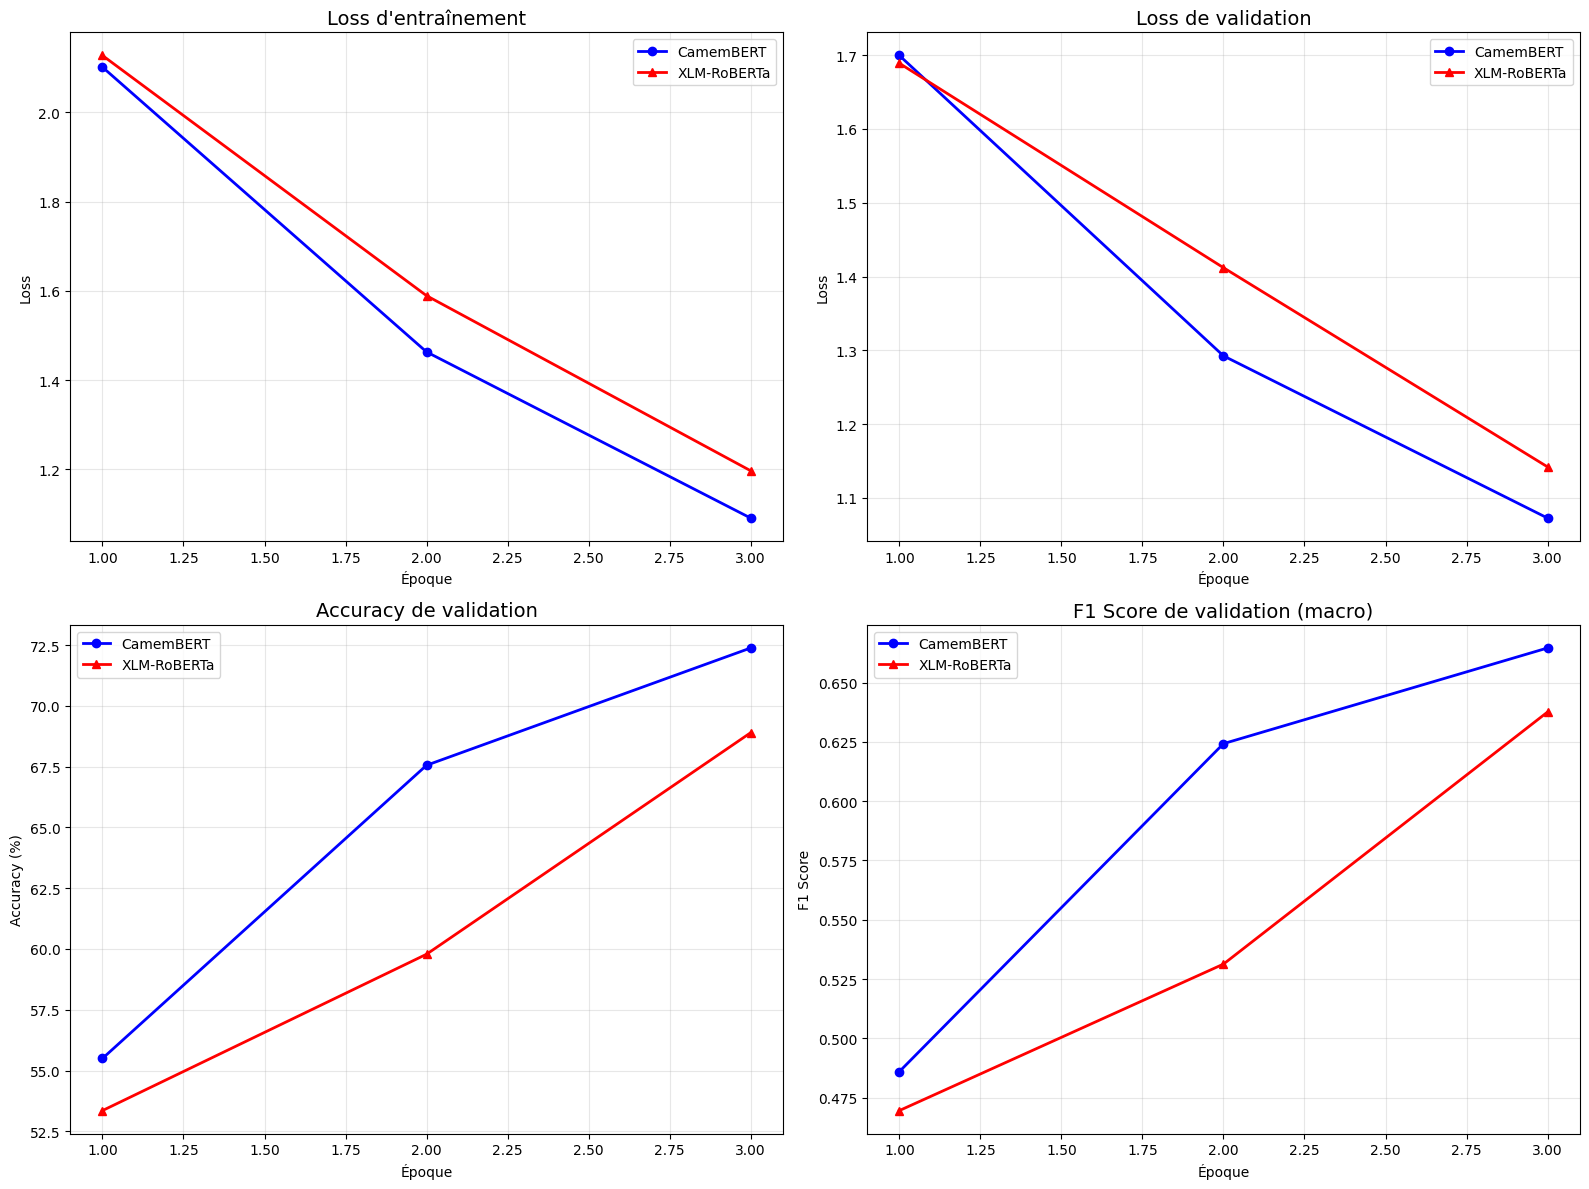

In [28]:
# Courbes d'apprentissage comparatives
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
epochs = range(1, N_EPOCHS + 1)

# Loss d'entraînement
axes[0, 0].plot(epochs, camembert_history['train_loss'], 'b-o', label='CamemBERT', linewidth=2)
axes[0, 0].plot(epochs, xlmr_history['train_loss'], 'r-^', label='XLM-RoBERTa', linewidth=2)
axes[0, 0].set_title("Loss d'entraînement", fontsize=14)
axes[0, 0].set_xlabel('Époque')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Loss de validation
axes[0, 1].plot(epochs, camembert_history['val_loss'], 'b-o', label='CamemBERT', linewidth=2)
axes[0, 1].plot(epochs, xlmr_history['val_loss'], 'r-^', label='XLM-RoBERTa', linewidth=2)
axes[0, 1].set_title('Loss de validation', fontsize=14)
axes[0, 1].set_xlabel('Époque')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Accuracy de validation
axes[1, 0].plot(epochs, [acc*100 for acc in camembert_history['val_acc']], 'b-o', label='CamemBERT', linewidth=2)
axes[1, 0].plot(epochs, [acc*100 for acc in xlmr_history['val_acc']], 'r-^', label='XLM-RoBERTa', linewidth=2)
axes[1, 0].set_title('Accuracy de validation', fontsize=14)
axes[1, 0].set_xlabel('Époque')
axes[1, 0].set_ylabel('Accuracy (%)')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# F1 Score de validation
axes[1, 1].plot(epochs, camembert_history['val_f1'], 'b-o', label='CamemBERT', linewidth=2)
axes[1, 1].plot(epochs, xlmr_history['val_f1'], 'r-^', label='XLM-RoBERTa', linewidth=2)
axes[1, 1].set_title('F1 Score de validation (macro)', fontsize=14)
axes[1, 1].set_xlabel('Époque')
axes[1, 1].set_ylabel('F1 Score')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Les quatre graphiques montrent l'évolution des métriques au cours de l'entraînement. On observe que CamemBERT (bleu) maintient un avantage constant sur XLM-RoBERTa (rouge) tout au long de l'entraînement, tant pour la loss que pour l'accuracy et le F1 score. Les courbes ne montrent pas de signes d'overfitting majeur, suggérant qu'un entraînement plus long pourrait encore améliorer les résultats.

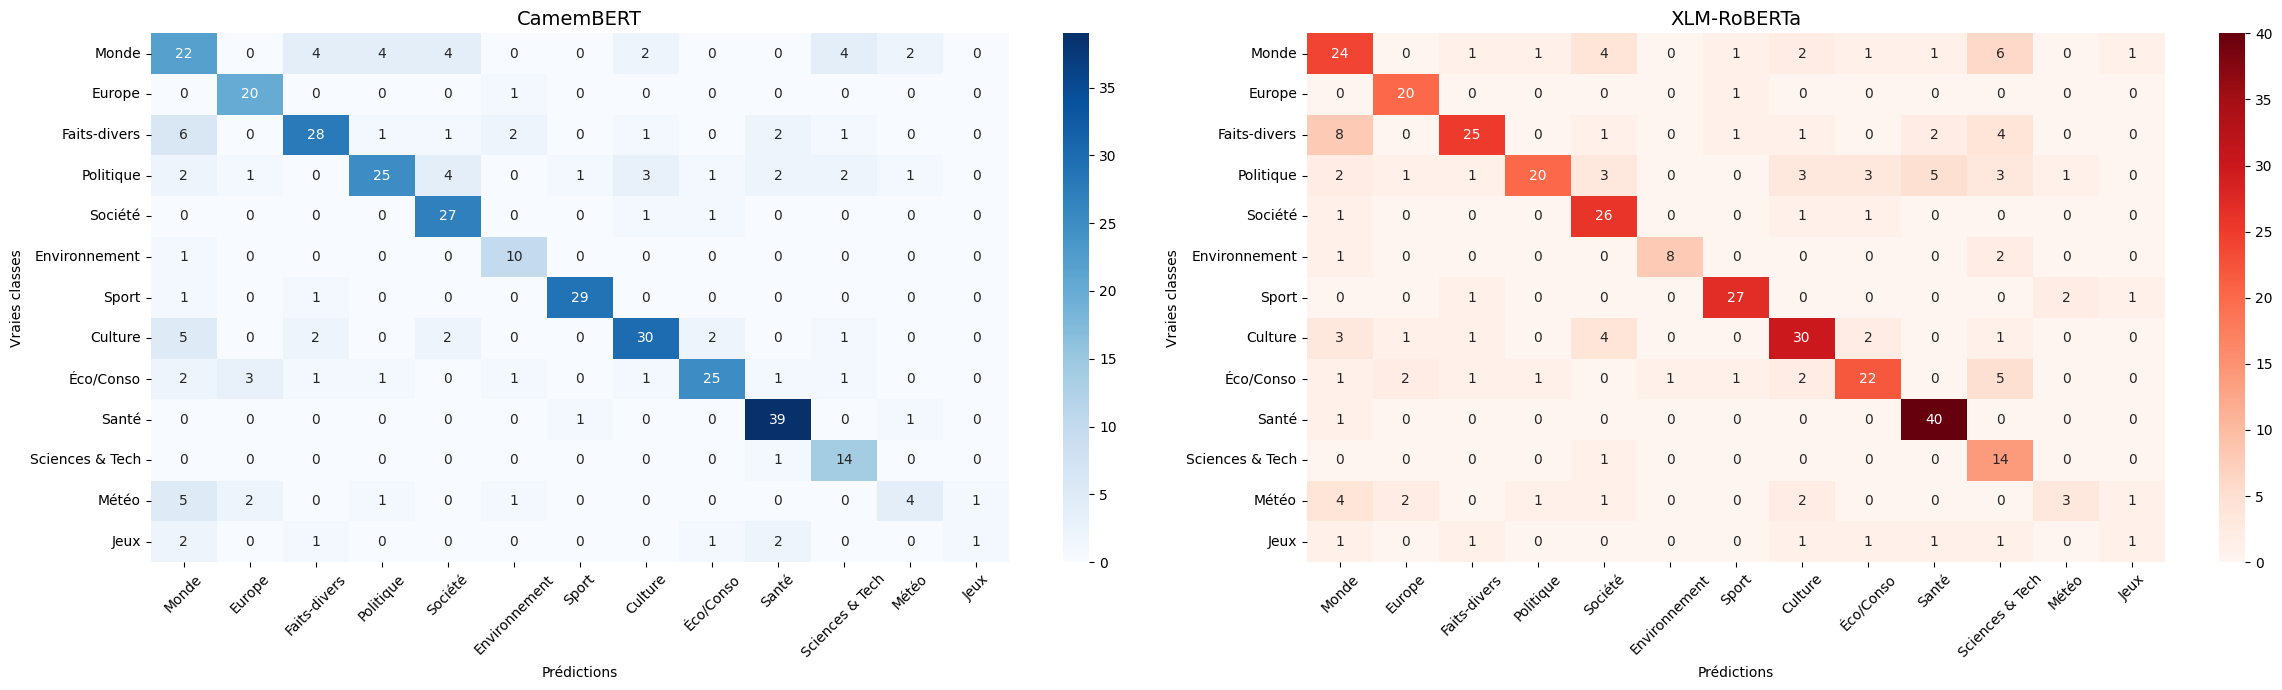

In [ ]:
# Matrices de confusion pour les 2 modèles
fig, axes = plt.subplots(1, 2, figsize=(24, 7))
class_names = list(CATEGORY_TO_ID.keys())

# CamemBERT
cm_camembert = confusion_matrix(camembert_true, camembert_preds)
sns.heatmap(cm_camembert, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names, ax=axes[0])
axes[0].set_title('CamemBERT', fontsize=14)
axes[0].set_xlabel('Prédictions')
axes[0].set_ylabel('Vraies classes')
axes[0].tick_params(axis='x', rotation=45)

# XLM-RoBERTa
cm_xlmr = confusion_matrix(xlmr_true, xlmr_preds)
sns.heatmap(cm_xlmr, annot=True, fmt='d', cmap='Reds', 
            xticklabels=class_names, yticklabels=class_names, ax=axes[1])
axes[1].set_title('XLM-RoBERTa', fontsize=14)
axes[1].set_xlabel('Prédictions')
axes[1].set_ylabel('Vraies classes')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Les matrices de confusion révèlent des performances globalement satisfaisantes pour les deux modèles, avec des diagonales bien marquées indiquant une majorité de prédictions correctes.

**CamemBERT** présente une diagonale très nette avec peu de dispersion hors-diagonale. Les classes les mieux prédites sont **Santé** (39/40 correctes), **Culture** (30/32) et **Sport** (29/30). On observe quelques confusions récurrentes : la catégorie **Monde** est parfois confondue avec **Faits-divers** (4 erreurs) et **Politique** (4 erreurs), ce qui s'explique par le chevauchement thématique de ces actualités internationales. La classe **Sciences & Tech** montre une performance plus faible avec seulement 14/15 articles correctement classés.

**XLM-RoBERTa** affiche une distribution plus dispersée avec davantage d'erreurs hors-diagonale. Si les performances sur **Santé** (40/41) et **Sport** (27/28) restent excellentes, on note une confusion plus marquée pour **Monde** qui se disperse vers plusieurs catégories (6 erreurs vers Météo, 4 vers Société). La classe **Éco/Conso** présente également plus de difficultés avec 22/33 correctes.

En termes de comparaison, CamemBERT semble produire des erreurs plus localisées et prévisibles, tandis que XLM-RoBERTa montre une tendance à disperser ses erreurs sur un plus grand nombre de classes. Cette observation suggère que le modèle francophone CamemBERT capture mieux les nuances linguistiques spécifiques au corpus d'actualités françaises, là où le modèle multilingue XLM-RoBERTa peut être influencé par des patterns appris sur d'autres langues.

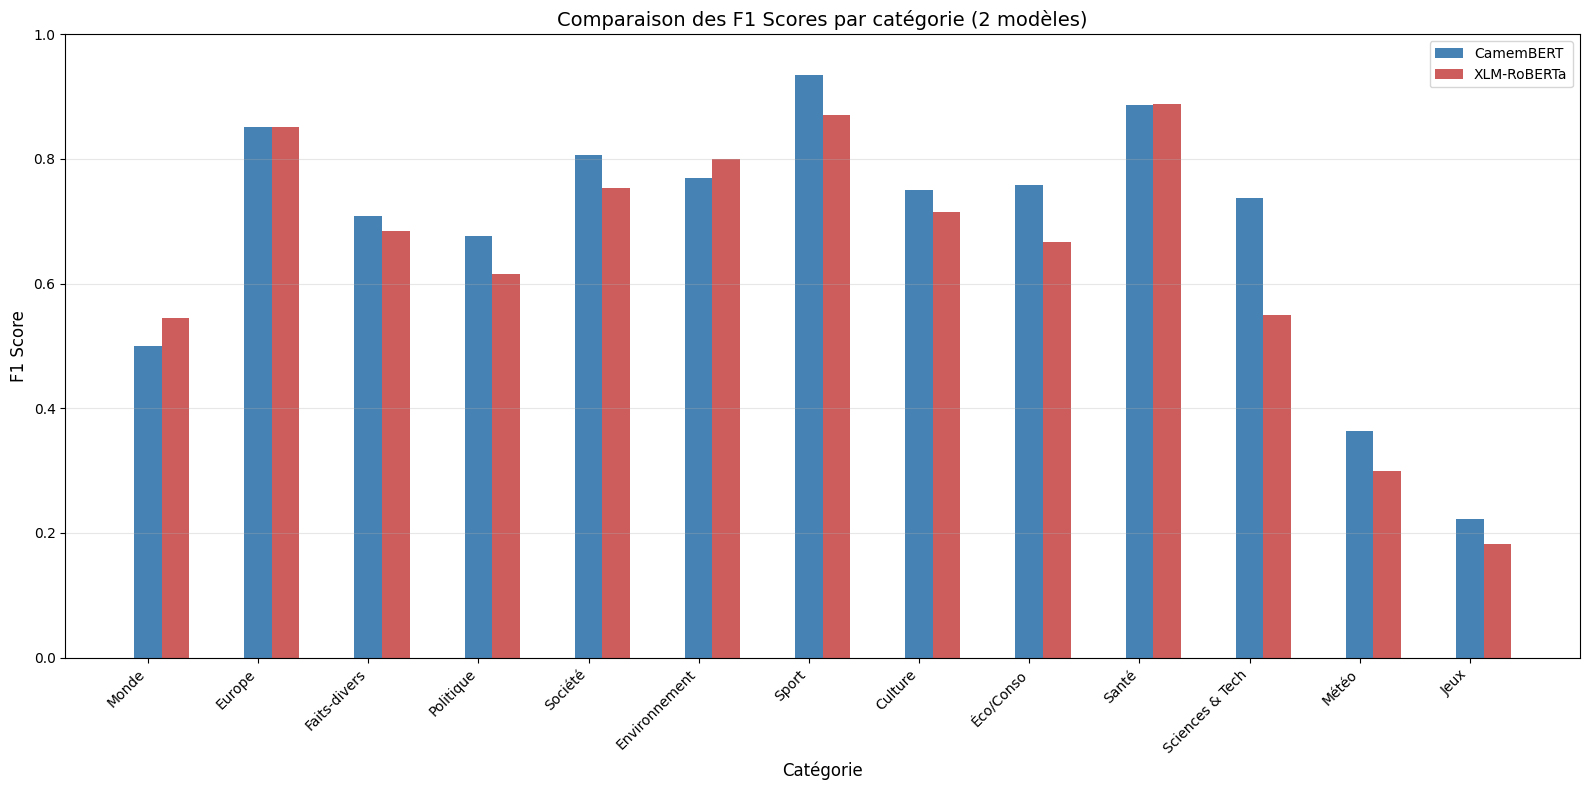

In [30]:
# Comparaison des F1 scores par classe
camembert_metrics = precision_recall_fscore_support(camembert_true, camembert_preds, average=None, zero_division=0)
xlmr_metrics = precision_recall_fscore_support(xlmr_true, xlmr_preds, average=None, zero_division=0)

fig, ax = plt.subplots(figsize=(16, 8))
x = np.arange(len(class_names))
width = 0.25

bars1 = ax.bar(x, camembert_metrics[2][:len(class_names)], width, label='CamemBERT', color='steelblue')
bars2 = ax.bar(x + width, xlmr_metrics[2][:len(class_names)], width, label='XLM-RoBERTa', color='indianred')

ax.set_xlabel('Catégorie', fontsize=12)
ax.set_ylabel('F1 Score', fontsize=12)
ax.set_title('Comparaison des F1 Scores par catégorie (2 modèles)', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(class_names, rotation=45, ha='right')
ax.legend(loc='upper right')
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [31]:
# Tableau détaillé des performances par classe
print("PERFORMANCES DÉTAILLÉES PAR CLASSE")
print("-"*80)

metrics_data = []
for i, class_name in enumerate(class_names):
    if i < len(camembert_metrics[2]):
        metrics_data.append({
            'Classe': class_name,
            'CamemBERT F1': f"{camembert_metrics[2][i]:.3f}",
            'XLM-RoBERTa F1': f"{xlmr_metrics[2][i]:.3f}",
            'Meilleur': ['CamemBERT','XLM-RoBERTa'][
                np.argmax([camembert_metrics[2][i], xlmr_metrics[2][i]])
            ]
        })

metrics_df = pd.DataFrame(metrics_data)
print(metrics_df.to_string(index=False))

PERFORMANCES DÉTAILLÉES PAR CLASSE
--------------------------------------------------------------------------------
         Classe CamemBERT F1 XLM-RoBERTa F1    Meilleur
          Monde        0.500          0.545 XLM-RoBERTa
         Europe        0.851          0.851   CamemBERT
   Faits-divers        0.709          0.685   CamemBERT
      Politique        0.676          0.615   CamemBERT
        Société        0.806          0.754   CamemBERT
  Environnement        0.769          0.800 XLM-RoBERTa
          Sport        0.935          0.871   CamemBERT
        Culture        0.750          0.714   CamemBERT
      Éco/Conso        0.758          0.667   CamemBERT
          Santé        0.886          0.889 XLM-RoBERTa
Sciences & Tech        0.737          0.549   CamemBERT
          Météo        0.364          0.300   CamemBERT
           Jeux        0.222          0.182   CamemBERT


In [32]:
# Analyse des erreurs pour chaque modèle
def top_confusions(true_labels, predictions, model_name, n=5):
    confusion_pairs = []
    for true, pred in zip(true_labels, predictions):
        if true != pred:
            confusion_pairs.append((ID_TO_CATEGORY[true], ID_TO_CATEGORY[pred]))
    
    top = Counter(confusion_pairs).most_common(n)
    
    print(f"\n--- {model_name} : Top {n} confusions ---")
    for (true_class, pred_class), count in top:
        print(f"  {true_class} -> {pred_class} : {count} fois")

top_confusions(camembert_true, camembert_preds, "CamemBERT")
top_confusions(xlmr_true, xlmr_preds, "XLM-RoBERTa")


--- CamemBERT : Top 5 confusions ---
  Faits-divers -> Monde : 6 fois
  Météo -> Monde : 5 fois
  Culture -> Monde : 5 fois
  Monde -> Société : 4 fois
  Monde -> Politique : 4 fois

--- XLM-RoBERTa : Top 5 confusions ---
  Faits-divers -> Monde : 8 fois
  Monde -> Sciences & Tech : 6 fois
  Politique -> Santé : 5 fois
  Éco/Conso -> Sciences & Tech : 5 fois
  Monde -> Société : 4 fois


In [34]:
# Résumé final
print("RÉSUMÉ FINAL")
print("-"*80)

print(f"""
Dataset : gustavecortal/diverse_french_news
Nombre de classes : {NUM_CLASSES}
Classes : {', '.join(class_names)}

RÉSULTATS FINAUX :

  1. CamemBERT (~110M paramètres)
     - Accuracy : {camembert_test_acc*100:.2f}%
     - F1 Score : {camembert_test_f1:.4f}
  
  2. XLM-RoBERTa (~270M paramètres)
     - Accuracy : {xlmr_test_acc*100:.2f}%
     - F1 Score : {xlmr_test_f1:.4f}

MEILLEUR MODÈLE : {best_model}
""")

RÉSUMÉ FINAL
--------------------------------------------------------------------------------

Dataset : gustavecortal/diverse_french_news
Nombre de classes : 13
Classes : Monde, Europe, Faits-divers, Politique, Société, Environnement, Sport, Culture, Éco/Conso, Santé, Sciences & Tech, Météo, Jeux

RÉSULTATS FINAUX :

  1. CamemBERT (~110M paramètres)
     - Accuracy : 73.46%
     - F1 Score : 0.6895
  
  2. XLM-RoBERTa (~270M paramètres)
     - Accuracy : 69.71%
     - F1 Score : 0.6479

MEILLEUR MODÈLE : CamemBERT



#### **Parie II: Fine-tunning**

In [35]:
# Paramètres
NUM_CLASSES = len(CATEGORY_TO_ID)
MAX_LENGTH = 256
BATCH_SIZE = 16
N_EPOCHS = 5 
LEARNING_RATE = 3e-5

N_TRAIN = len(df_train)
N_VAL = len(df_val)
N_TEST = len(df_test)

print(f"Configuration :")
print(f"  - Classes : {NUM_CLASSES}")
print(f"  - Max length : {MAX_LENGTH}")
print(f"  - Batch size : {BATCH_SIZE}")
print(f"  - Epochs : {N_EPOCHS}")
print(f"  - Learning rate : {LEARNING_RATE}")
print(f"  - Échantillons : {N_TRAIN} / {N_VAL} / {N_TEST}")

Configuration :
  - Classes : 13
  - Max length : 256
  - Batch size : 16
  - Epochs : 5
  - Learning rate : 3e-05
  - Échantillons : 17980 / 538 / 550


##### **1. CamemBERT**

In [36]:
# Chargement de CamemBERT
print("Chargement de CamemBERT...")
camembert_tokenizer = CamembertTokenizer.from_pretrained('camembert-base')
camembert_base = CamembertModel.from_pretrained('camembert-base')

print(f"\nConfiguration de CamemBERT :")
print(f"  - Hidden size : {camembert_base.config.hidden_size}")
print(f"  - Num layers : {camembert_base.config.num_hidden_layers}")
print(f"  - Vocab size : {camembert_base.config.vocab_size}")

Chargement de CamemBERT...

Configuration de CamemBERT :
  - Hidden size : 768
  - Num layers : 12
  - Vocab size : 32005


In [37]:
# Test du tokenizer
test_sentence = "Le président de la République a annoncé de nouvelles mesures."
tokens = camembert_tokenizer.tokenize(test_sentence)
print(f"Phrase : {test_sentence}")
print(f"Tokens : {tokens}")
print(f"Nombre de tokens : {len(tokens)}")

Phrase : Le président de la République a annoncé de nouvelles mesures.
Tokens : ['▁Le', '▁président', '▁de', '▁la', '▁République', '▁a', '▁annoncé', '▁de', '▁nouvelles', '▁mesures', '.']
Nombre de tokens : 11


In [38]:
# Création du modèle et DataLoaders
camembert_classifier = TransformerClassifier(camembert_base, NUM_CLASSES)
camembert_classifier.to(DEVICE)

camembert_train_loader, camembert_val_loader, camembert_test_loader = create_dataloaders(
    camembert_tokenizer, df_train_sample, df_val_sample, df_test_sample,
    batch_size=BATCH_SIZE, max_length=MAX_LENGTH
)

print(f"Modèle CamemBERT : {sum(p.numel() for p in camembert_classifier.parameters()):,} paramètres")
print(f"Train batches : {len(camembert_train_loader)}")
print(f"Val batches : {len(camembert_val_loader)}")
print(f"Test batches : {len(camembert_test_loader)}")

Modèle CamemBERT : 110,631,949 paramètres
Train batches : 299
Val batches : 24
Test batches : 24


In [39]:
# Entraînement de CamemBERT
camembert_history = train_model(
    camembert_classifier,
    camembert_train_loader,
    camembert_val_loader,
    n_epochs=N_EPOCHS,
    learning_rate=LEARNING_RATE,
    device=DEVICE,
    model_name="CamemBERT"
)

Entraînement de CamemBERT
------------------------------------------------------------

Époque 1/5
----------------------------------------


Training:   0%|          | 0/299 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/24 [00:00<?, ?it/s]

  Train Loss: 2.1006 | Train Acc: 43.08%
  Val Loss: 1.7111 | Val Acc: 55.76% | Val F1: 0.4905

Époque 2/5
----------------------------------------


Training:   0%|          | 0/299 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/24 [00:00<?, ?it/s]

  Train Loss: 0.8470 | Train Acc: 81.94%
  Val Loss: 1.0185 | Val Acc: 73.19% | Val F1: 0.6707

Époque 5/5
----------------------------------------


Training:   0%|          | 0/299 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/24 [00:00<?, ?it/s]

  Train Loss: 0.6830 | Train Acc: 85.45%
  Val Loss: 0.9720 | Val Acc: 73.46% | Val F1: 0.6866


In [40]:
# Évaluation finale CamemBERT
print("ÉVALUATION FINALE - CamemBERT")
print("-"*60)

criterion = nn.CrossEntropyLoss()
camembert_test_loss, camembert_test_acc, camembert_test_f1, camembert_preds, camembert_true = evaluate(
    camembert_classifier, camembert_test_loader, criterion, DEVICE
)

print(f"\nRésultats sur le test set :")
print(f"  - Loss : {camembert_test_loss:.4f}")
print(f"  - Accuracy : {camembert_test_acc*100:.2f}%")
print(f"  - F1 Score (macro) : {camembert_test_f1:.4f}")

print("\nRapport de classification :")
print(classification_report(camembert_true, camembert_preds, target_names=list(CATEGORY_TO_ID.keys())))

ÉVALUATION FINALE - CamemBERT
------------------------------------------------------------


Evaluating:   0%|          | 0/24 [00:00<?, ?it/s]


Résultats sur le test set :
  - Loss : 0.9959
  - Accuracy : 74.80%
  - F1 Score (macro) : 0.7192

Rapport de classification :
                 precision    recall  f1-score   support

          Monde       0.89      0.38      0.53        42
         Europe       0.79      0.90      0.84        21
   Faits-divers       0.71      0.71      0.71        42
      Politique       0.83      0.57      0.68        42
        Société       0.77      0.83      0.80        29
  Environnement       0.91      0.91      0.91        11
          Sport       0.94      0.97      0.95        31
        Culture       0.65      0.88      0.75        42
      Éco/Conso       0.85      0.78      0.81        36
          Santé       0.86      0.90      0.88        41
Sciences & Tech       0.61      0.93      0.74        15
          Météo       0.32      0.57      0.41        14
           Jeux       0.40      0.29      0.33         7

       accuracy                           0.75       373
      macro avg

##### **2. XLM-RoBERTa**

In [41]:
# Chargement de XLM-RoBERTa
print("Chargement de XLM-RoBERTa...")
xlmr_tokenizer = XLMRobertaTokenizer.from_pretrained('xlm-roberta-base')
xlmr_base = XLMRobertaModel.from_pretrained('xlm-roberta-base')

print(f"\nConfiguration de XLM-RoBERTa :")
print(f"  - Hidden size : {xlmr_base.config.hidden_size}")
print(f"  - Num layers : {xlmr_base.config.num_hidden_layers}")
print(f"  - Vocab size : {xlmr_base.config.vocab_size}")

Chargement de XLM-RoBERTa...

Configuration de XLM-RoBERTa :
  - Hidden size : 768
  - Num layers : 12
  - Vocab size : 250002


In [42]:
# Création du modèle XLM-RoBERTa
xlmr_classifier = TransformerClassifier(xlmr_base, NUM_CLASSES)
xlmr_classifier.to(DEVICE)

print(f"Modèle XLM-RoBERTa Classifier créé.")
print(f"Nombre de paramètres : {sum(p.numel() for p in xlmr_classifier.parameters()):,}")

Modèle XLM-RoBERTa Classifier créé.
Nombre de paramètres : 278,053,645


In [43]:
# DataLoaders pour XLM-RoBERTa
xlmr_train_loader, xlmr_val_loader, xlmr_test_loader = create_dataloaders(
    xlmr_tokenizer, df_train_sample, df_val_sample, df_test_sample,
    batch_size=BATCH_SIZE, max_length=MAX_LENGTH
)
print("DataLoaders créés pour XLM-RoBERTa.")

DataLoaders créés pour XLM-RoBERTa.


In [44]:
# Entraînement de XLM-RoBERTa
xlmr_history = train_model(
    xlmr_classifier,
    xlmr_train_loader,
    xlmr_val_loader,
    n_epochs=N_EPOCHS,
    learning_rate=LEARNING_RATE,
    device=DEVICE,
    model_name="XLM-RoBERTa"
)

Entraînement de XLM-RoBERTa
------------------------------------------------------------

Époque 1/5
----------------------------------------


Training:   0%|          | 0/299 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/24 [00:00<?, ?it/s]

  Train Loss: 2.1957 | Train Acc: 31.23%
  Val Loss: 1.6651 | Val Acc: 54.96% | Val F1: 0.4825

Époque 2/5
----------------------------------------


Training:   0%|          | 0/299 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/24 [00:00<?, ?it/s]

  Train Loss: 0.8688 | Train Acc: 75.50%
  Val Loss: 1.0428 | Val Acc: 68.63% | Val F1: 0.6294

Époque 5/5
----------------------------------------


Training:   0%|          | 0/299 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/24 [00:00<?, ?it/s]

  Train Loss: 0.8042 | Train Acc: 76.88%
  Val Loss: 1.0235 | Val Acc: 71.31% | Val F1: 0.6748


In [46]:
# Évaluation finale XLM-RoBERTa
print("ÉVALUATION FINALE - XLM-RoBERTa")
print("-"*60)

xlmr_test_loss, xlmr_test_acc, xlmr_test_f1, xlmr_preds, xlmr_true = evaluate(
    xlmr_classifier, xlmr_test_loader, criterion, DEVICE
)

print(f"\nRésultats sur le test set :")
print(f"  - Loss : {xlmr_test_loss:.4f}")
print(f"  - Accuracy : {xlmr_test_acc*100:.2f}%")
print(f"  - F1 Score (macro) : {xlmr_test_f1:.4f}")

print("\nRapport de classification :")
print(classification_report(xlmr_true, xlmr_preds, target_names=list(CATEGORY_TO_ID.keys())))

ÉVALUATION FINALE - XLM-RoBERTa
------------------------------------------------------------


Evaluating:   0%|          | 0/24 [00:00<?, ?it/s]


Résultats sur le test set :
  - Loss : 0.9564
  - Accuracy : 72.39%
  - F1 Score (macro) : 0.6858

Rapport de classification :
                 precision    recall  f1-score   support

          Monde       0.65      0.48      0.55        42
         Europe       0.88      0.71      0.79        21
   Faits-divers       0.77      0.81      0.79        42
      Politique       0.85      0.69      0.76        42
        Société       0.68      0.79      0.73        29
  Environnement       0.82      0.82      0.82        11
          Sport       0.93      0.87      0.90        31
        Culture       0.76      0.83      0.80        42
      Éco/Conso       0.76      0.72      0.74        36
          Santé       0.88      0.73      0.80        41
Sciences & Tech       0.58      0.93      0.72        15
          Météo       0.21      0.50      0.30        14
           Jeux       0.50      0.14      0.22         7

       accuracy                           0.72       373
      macro avg

##### **3. Comparaison des résultats**

In [47]:
# Tableau comparatif des 3 modèles
print("COMPARAISON DES 2 MODÈLES")
print("-"*80)

comparison_data = {
    'Modèle': ['CamemBERT', 'XLM-RoBERTa'],
    'Paramètres': ['~110M', '~270M'],
    'Test Accuracy (%)': [
        f"{camembert_test_acc*100:.2f}", 
        f"{xlmr_test_acc*100:.2f}"
    ],
    'Test F1 (macro)': [
        f"{camembert_test_f1:.4f}", 
        f"{xlmr_test_f1:.4f}"
    ],
    'Test Loss': [
        f"{camembert_test_loss:.4f}", 
        f"{xlmr_test_loss:.4f}"
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))

# Déterminer le meilleur modèle
f1_scores = {
    'CamemBERT': camembert_test_f1,
    'XLM-RoBERTa': xlmr_test_f1
}
best_model = max(f1_scores, key=f1_scores.get)
print(f"\n>>> Meilleur modèle : {best_model} (F1 = {f1_scores[best_model]:.4f})")

COMPARAISON DES 2 MODÈLES
--------------------------------------------------------------------------------
     Modèle Paramètres Test Accuracy (%) Test F1 (macro) Test Loss
  CamemBERT      ~110M             74.80          0.7192    0.9959
XLM-RoBERTa      ~270M             72.39          0.6858    0.9564

>>> Meilleur modèle : CamemBERT (F1 = 0.7192)


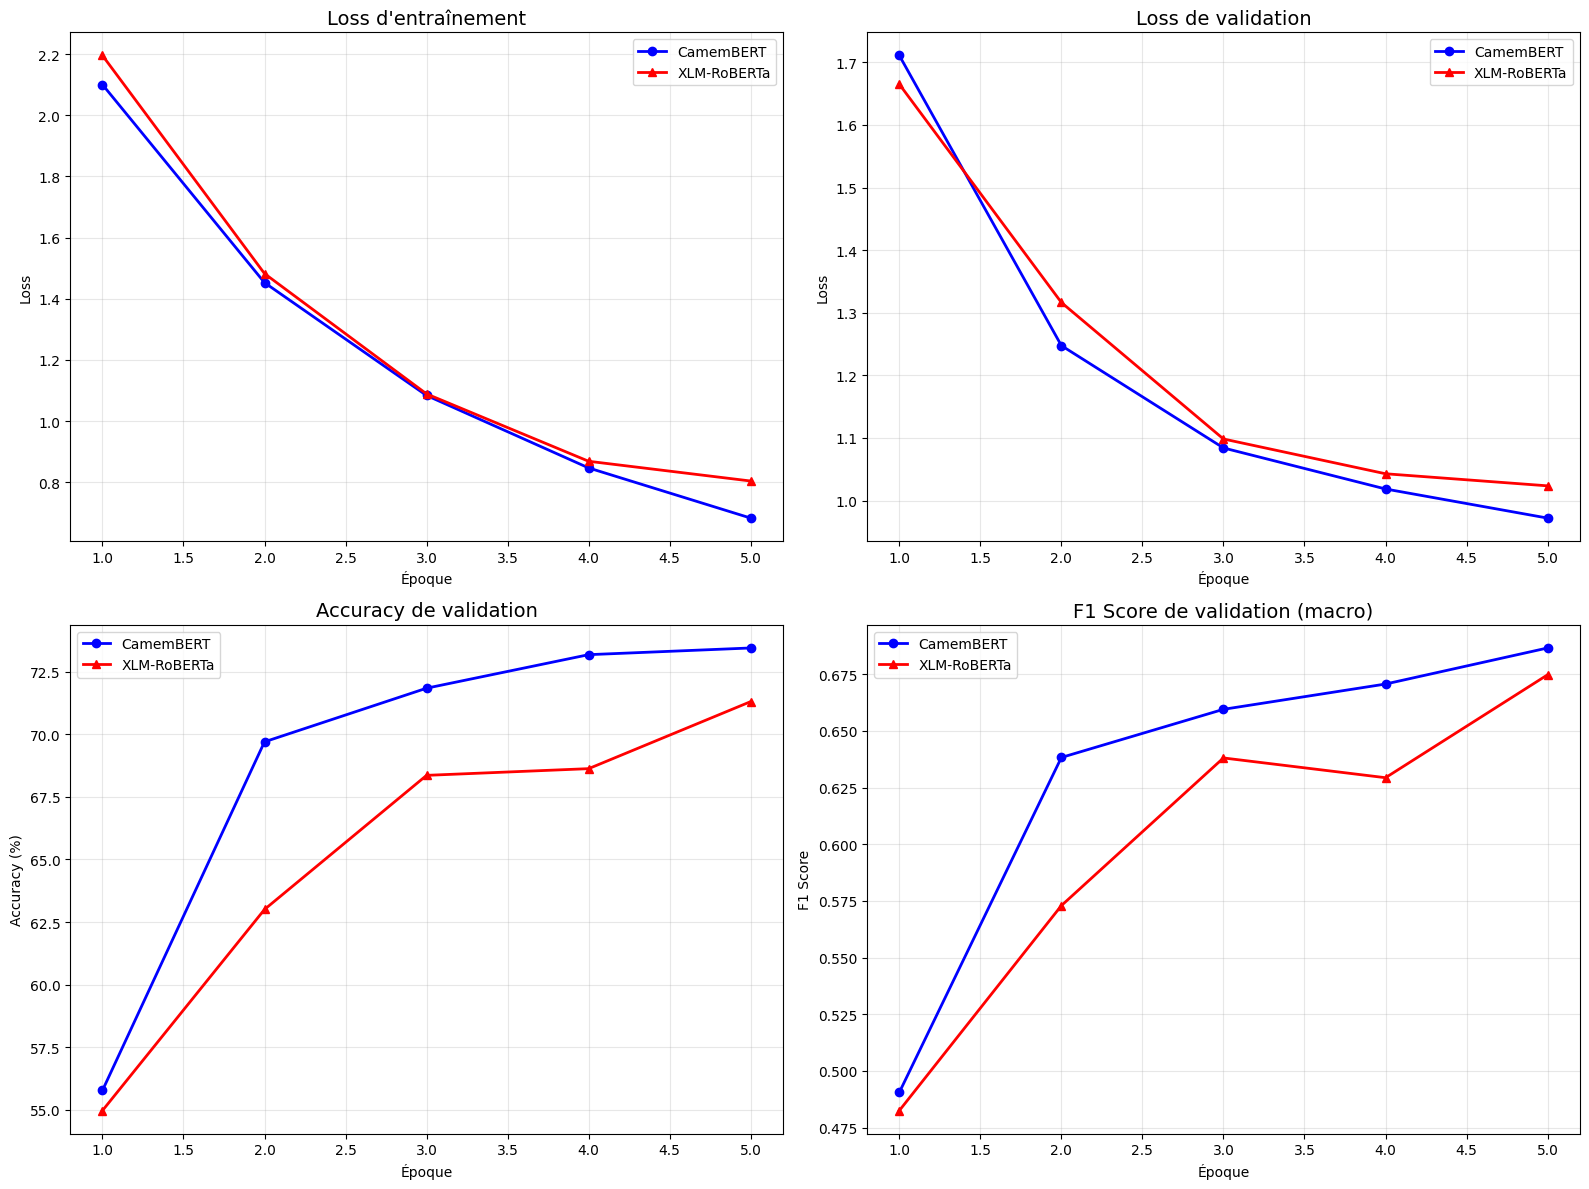

In [48]:
# Courbes d'apprentissage comparatives
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
epochs = range(1, N_EPOCHS + 1)

# Loss d'entraînement
axes[0, 0].plot(epochs, camembert_history['train_loss'], 'b-o', label='CamemBERT', linewidth=2)
axes[0, 0].plot(epochs, xlmr_history['train_loss'], 'r-^', label='XLM-RoBERTa', linewidth=2)
axes[0, 0].set_title("Loss d'entraînement", fontsize=14)
axes[0, 0].set_xlabel('Époque')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Loss de validation
axes[0, 1].plot(epochs, camembert_history['val_loss'], 'b-o', label='CamemBERT', linewidth=2)
axes[0, 1].plot(epochs, xlmr_history['val_loss'], 'r-^', label='XLM-RoBERTa', linewidth=2)
axes[0, 1].set_title('Loss de validation', fontsize=14)
axes[0, 1].set_xlabel('Époque')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Accuracy de validation
axes[1, 0].plot(epochs, [acc*100 for acc in camembert_history['val_acc']], 'b-o', label='CamemBERT', linewidth=2)
axes[1, 0].plot(epochs, [acc*100 for acc in xlmr_history['val_acc']], 'r-^', label='XLM-RoBERTa', linewidth=2)
axes[1, 0].set_title('Accuracy de validation', fontsize=14)
axes[1, 0].set_xlabel('Époque')
axes[1, 0].set_ylabel('Accuracy (%)')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# F1 Score de validation
axes[1, 1].plot(epochs, camembert_history['val_f1'], 'b-o', label='CamemBERT', linewidth=2)
axes[1, 1].plot(epochs, xlmr_history['val_f1'], 'r-^', label='XLM-RoBERTa', linewidth=2)
axes[1, 1].set_title('F1 Score de validation (macro)', fontsize=14)
axes[1, 1].set_xlabel('Époque')
axes[1, 1].set_ylabel('F1 Score')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

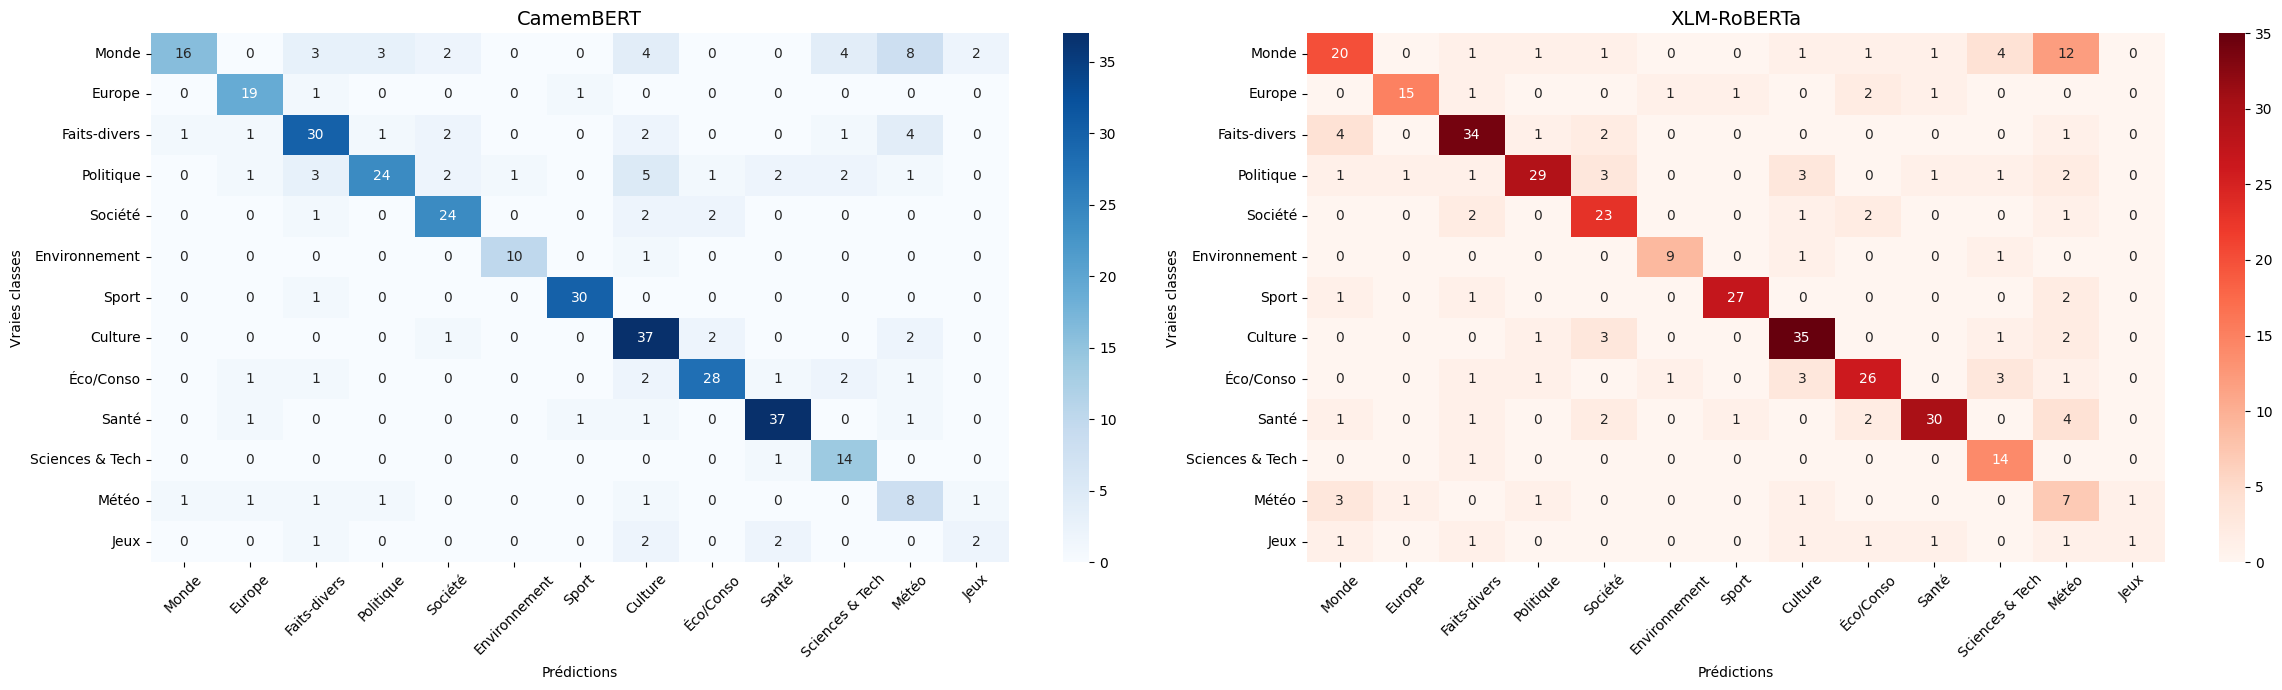

In [49]:
# Matrices de confusion pour les 2 modèles
fig, axes = plt.subplots(1, 2, figsize=(24, 7))
class_names = list(CATEGORY_TO_ID.keys())

# CamemBERT
cm_camembert = confusion_matrix(camembert_true, camembert_preds)
sns.heatmap(cm_camembert, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names, ax=axes[0])
axes[0].set_title('CamemBERT', fontsize=14)
axes[0].set_xlabel('Prédictions')
axes[0].set_ylabel('Vraies classes')
axes[0].tick_params(axis='x', rotation=45)

# XLM-RoBERTa
cm_xlmr = confusion_matrix(xlmr_true, xlmr_preds)
sns.heatmap(cm_xlmr, annot=True, fmt='d', cmap='Reds', 
            xticklabels=class_names, yticklabels=class_names, ax=axes[1])
axes[1].set_title('XLM-RoBERTa', fontsize=14)
axes[1].set_xlabel('Prédictions')
axes[1].set_ylabel('Vraies classes')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

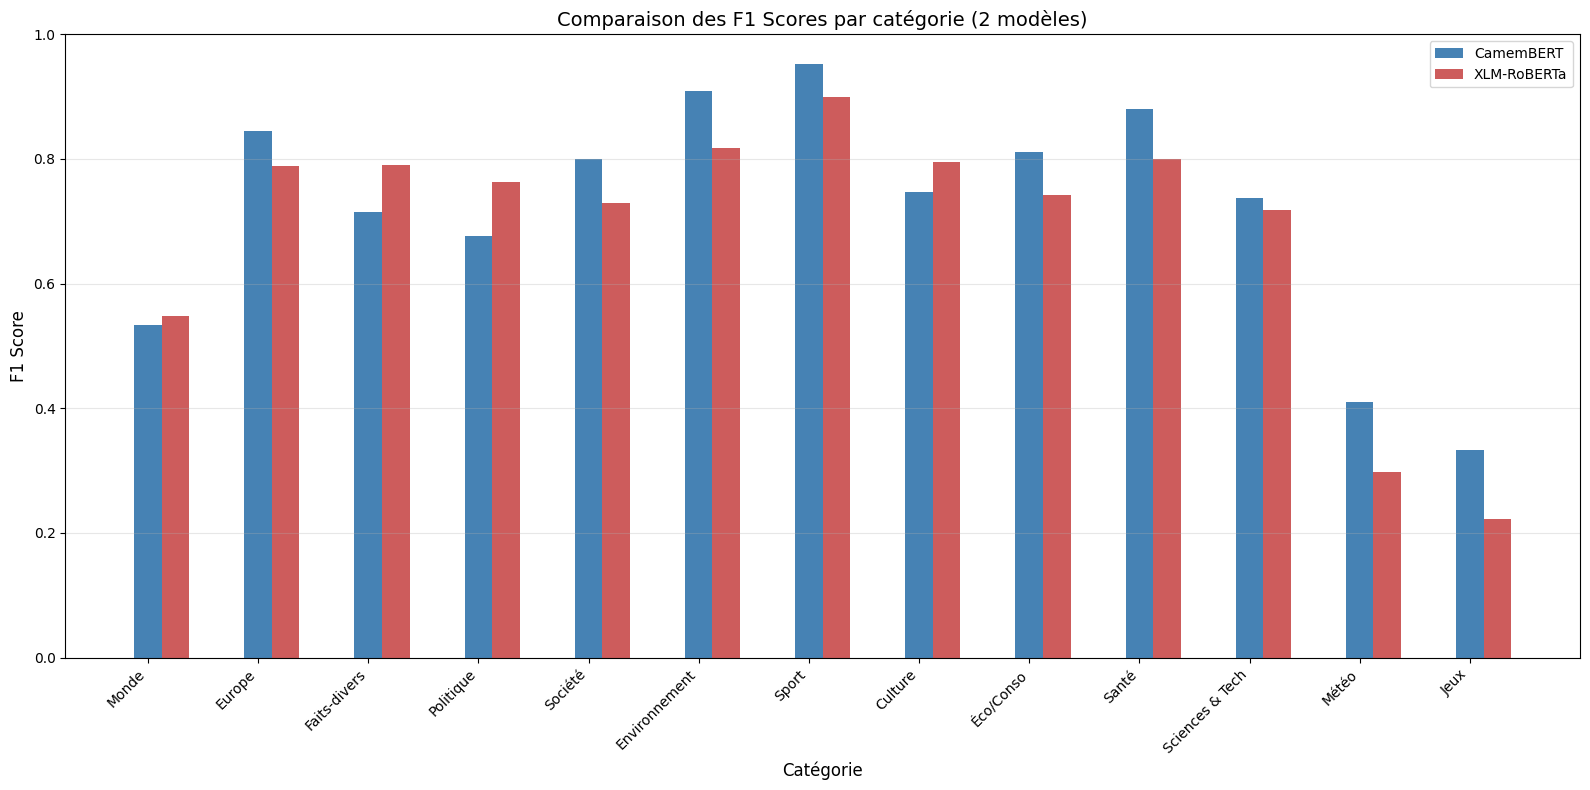

In [51]:
# Comparaison des F1 scores par classe
camembert_metrics = precision_recall_fscore_support(camembert_true, camembert_preds, average=None, zero_division=0)
xlmr_metrics = precision_recall_fscore_support(xlmr_true, xlmr_preds, average=None, zero_division=0)

fig, ax = plt.subplots(figsize=(16, 8))
x = np.arange(len(class_names))
width = 0.25

bars1 = ax.bar(x, camembert_metrics[2][:len(class_names)], width, label='CamemBERT', color='steelblue')
bars2 = ax.bar(x + width, xlmr_metrics[2][:len(class_names)], width, label='XLM-RoBERTa', color='indianred')

ax.set_xlabel('Catégorie', fontsize=12)
ax.set_ylabel('F1 Score', fontsize=12)
ax.set_title('Comparaison des F1 Scores par catégorie (2 modèles)', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(class_names, rotation=45, ha='right')
ax.legend(loc='upper right')
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [54]:
# Tableau détaillé des performances par classe
print("PERFORMANCES DÉTAILLÉES PAR CLASSE")
print("-"*80)

metrics_data = []
for i, class_name in enumerate(class_names):
    if i < len(camembert_metrics[2]):
        metrics_data.append({
            'Classe': class_name,
            'CamemBERT F1': f"{camembert_metrics[2][i]:.3f}",
            'XLM-RoBERTa F1': f"{xlmr_metrics[2][i]:.3f}",
            'Meilleur': ['CamemBERT', 'XLM-RoBERTa'][
                np.argmax([camembert_metrics[2][i], xlmr_metrics[2][i]])
            ]
        })

metrics_df = pd.DataFrame(metrics_data)
print(metrics_df.to_string(index=False))

PERFORMANCES DÉTAILLÉES PAR CLASSE
--------------------------------------------------------------------------------
         Classe CamemBERT F1 XLM-RoBERTa F1    Meilleur
          Monde        0.533          0.548 XLM-RoBERTa
         Europe        0.844          0.789   CamemBERT
   Faits-divers        0.714          0.791 XLM-RoBERTa
      Politique        0.676          0.763 XLM-RoBERTa
        Société        0.800          0.730   CamemBERT
  Environnement        0.909          0.818   CamemBERT
          Sport        0.952          0.900   CamemBERT
        Culture        0.747          0.795 XLM-RoBERTa
      Éco/Conso        0.812          0.743   CamemBERT
          Santé        0.881          0.800   CamemBERT
Sciences & Tech        0.737          0.718   CamemBERT
          Météo        0.410          0.298   CamemBERT
           Jeux        0.333          0.222   CamemBERT


In [55]:
# Analyse des erreurs pour chaque modèle
def top_confusions(true_labels, predictions, model_name, n=5):
    confusion_pairs = []
    for true, pred in zip(true_labels, predictions):
        if true != pred:
            confusion_pairs.append((ID_TO_CATEGORY[true], ID_TO_CATEGORY[pred]))
    
    top = Counter(confusion_pairs).most_common(n)
    
    print(f"\n--- {model_name} : Top {n} confusions ---")
    for (true_class, pred_class), count in top:
        print(f"  {true_class} -> {pred_class} : {count} fois")

top_confusions(camembert_true, camembert_preds, "CamemBERT")
top_confusions(xlmr_true, xlmr_preds, "XLM-RoBERTa")


--- CamemBERT : Top 5 confusions ---
  Monde -> Météo : 8 fois
  Politique -> Culture : 5 fois
  Monde -> Culture : 4 fois
  Monde -> Sciences & Tech : 4 fois
  Faits-divers -> Météo : 4 fois

--- XLM-RoBERTa : Top 5 confusions ---
  Monde -> Météo : 12 fois
  Faits-divers -> Monde : 4 fois
  Monde -> Sciences & Tech : 4 fois
  Santé -> Météo : 4 fois
  Politique -> Société : 3 fois


In [56]:
# Résumé final
print("RÉSUMÉ FINAL")
print("-"*80)

print(f"""
Dataset : gustavecortal/diverse_french_news
Nombre de classes : {NUM_CLASSES}
Classes : {', '.join(class_names)}

RÉSULTATS FINAUX :

  1. CamemBERT (~110M paramètres)
     - Accuracy : {camembert_test_acc*100:.2f}%
     - F1 Score : {camembert_test_f1:.4f}
  
  3. XLM-RoBERTa (~270M paramètres)
     - Accuracy : {xlmr_test_acc*100:.2f}%
     - F1 Score : {xlmr_test_f1:.4f}

MEILLEUR MODÈLE : {best_model}
""")

RÉSUMÉ FINAL
--------------------------------------------------------------------------------

Dataset : gustavecortal/diverse_french_news
Nombre de classes : 13
Classes : Monde, Europe, Faits-divers, Politique, Société, Environnement, Sport, Culture, Éco/Conso, Santé, Sciences & Tech, Météo, Jeux

RÉSULTATS FINAUX :

  1. CamemBERT (~110M paramètres)
     - Accuracy : 74.80%
     - F1 Score : 0.7192
  
  3. XLM-RoBERTa (~270M paramètres)
     - Accuracy : 72.39%
     - F1 Score : 0.6858

MEILLEUR MODÈLE : CamemBERT



#### **9. Conclusion**
##### **9.1 Synthèse des résultats**
Cette étude comparative a permis d'évaluer les performances de deux modèles Transformer sur une tâche de classification d'articles de presse français en 13 catégories. Les principaux enseignements sont les suivants :
- CamemBERT obtient les meilleures performances (F1 = 0.7192, Accuracy = 74.80%), confirmant l'avantage de la spécialisation linguistique pour les tâches monolingues.
- XLM-RoBERTa, malgré sa taille supérieure (~270M paramètres), présente des performances inférieures (F1 = 0.6858), suggérant que le partage de capacité entre 100 langues dilue les représentations spécifiques au français.
- Les performances varient fortement selon les catégories : excellentes pour « Sport » (F1 = 0.952) et « Environnement » (F1 = 0.909), mais faibles pour « Météo » (F1 = 0.410) et « Jeux » (F1 = 0.333).
- Les principales sources d'erreurs proviennent de chevauchements sémantiques entre catégories (Monde/Météo, Politique/Société) et du déséquilibre des classes.

##### **9.2 Points d'amélioration**
Amélioration des données :
•	Data augmentation pour les classes sous-représentées (Météo, Jeux)
•	Enrichissement du dictionnaire de mots-clés avec des expressions contextuelles
•	Utilisation du texte complet de l'article en plus du titre et de la description
Amélioration du modèle :
•	Augmenter le nombre d'époques (5-10) avec early stopping
•	Optimisation des hyperparamètres avec Optuna ou Ray Tune
•	Utilisation de class weights pour compenser le déséquilibre
•	Test de CamemBERT-large (336M paramètres) pour potentiellement de meilleures performances
Amélioration de l'architecture :
•	Classification hiérarchique : d'abord les grandes catégories, puis les sous-catégories
•	Ensemble de modèles combinant CamemBERT et XLM-RoBERTa
•	Ajout d'une couche d'attention sur les mots-clés spécifiques à chaque catégorie

#### **9.3 Perspectives**
Ce projet constitue une base pour le développement d'un système de classification automatique d'articles de presse. Les résultats obtenus avec CamemBERT démontrent la viabilité de l'approche par fine-tuning de modèles pré-entraînés pour cette tâche.
Les pistes d'amélioration identifiées, notamment l'augmentation des données pour les classes minoritaires et l'optimisation des hyperparamètres, permettraient vraisemblablement d'atteindre des performances supérieures à 80% de F1 score, rendant le système utilisable en production pour l'aide à la catégorisation éditoriale.